<div style="width: 100%; overflow: hidden;">
    <div style="width: 150px; float: left;"> <img src="data/D4Sci_logo_ball.png" alt="Data For Science, Inc" align="left" border="0"> </div>
    <div style="float: left; margin-left: 10px;"> <h1>Classifiers</h1>
<h1>Model Output Detector</h1>
        <p>Bruno Gonçalves<br/>
        <a href="http://www.data4sci.com/">www.data4sci.com</a><br/>
            @bgoncalves, @data4sci</p></div>
</div>

In [1]:
import datetime
import json
import platform
import re
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
import transformers
from datasets import Dataset
from huggingface_hub import hf_hub_download
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score)
from sklearn.pipeline import Pipeline
from transformers import (AutoModelForSequenceClassification, AutoTokenizer,
                          DataCollatorWithPadding, Trainer, TrainingArguments)

import watermark

%load_ext watermark
%matplotlib inline

We start by print out the versions of the libraries we're using for future reference

In [2]:
%watermark -n -v -m -g -iv

Python implementation: CPython
Python version       : 3.14.6
IPython version      : 9.12.0

Compiler    : Clang 22.1.3 
OS          : Linux
Release     : 6.17.0-1026-nvidia
Machine     : aarch64
Processor   : aarch64
CPU cores   : 20
Architecture: 64bit

Git hash: f4f1589cdb1d01267b8945b8189ed68a75595728

datasets       : 5.0.0
huggingface_hub: 1.27.0
joblib         : 1.5.3
json           : 2.0.9
matplotlib     : 3.10.8
numpy          : 2.4.4
pandas         : 3.0.3
platform       : 1.0.9
re             : 2.2.1
sklearn        : 1.8.0
torch          : 2.11.0
transformers   : 5.5.4
watermark      : 2.6.0



Load default figure style

In [3]:
plt.style.use('d4sci.mplstyle')
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Start

This notebook closes the loop. The default-sampling generation notebook ran every model once over the HC3 questions, each at its vendor's own sampling defaults, and wrote everything to a single combined JSONL with the model name on every row. HC3 pairs every question with human-written answers and with ChatGPT answers from 2022. Here all three sources meet: your model generations, the human class, and the ChatGPT class, matched on the same prompts. A detector learns to name the author of each answer, and an analysis section takes the results apart: train against test, per-class scores, confusion structure, domain effects, confidence, calibration, and embedding geometry.

The detector is a fine-tuned ModernBERT. Every author in this pool writes fluent English about the same topics, so the separating signal lives in habits of phrasing — how a model hedges, which discourse connectives it reaches for, how it opens an explanation — and reading words in context is the right tool for that. A TF-IDF character n-gram baseline stays available behind the `TRAIN_BASELINE` flag: it fits in minutes on CPU, sets an honest floor, and unlocks the instance-by-instance comparison at the end that measures exactly what context buys over surface statistics.

Expectations: human vs any model should clear 95% at paragraph length, cross-family model pairs land above 90%, and same-family siblings — Qwen2.5 vs Qwen3, Mistral vs Ministral — probe the floor. A sibling score near chance is a finding, not a failure.

## Parameters

Model labels come from the `model` column of the combined JSONL, the GGUF filename stem, so every model is its own class. `ADD_HUMAN` and `ADD_CHATGPT` append the two HC3 classes. `HC3_FILE` must match the generation run, the prompt order depends on it. The split key is the prompt index: a prompt lands entirely in train or entirely in test across every class at once, which kills prompt leakage, the classic way detectors cheat.

The bottom block configures the ModernBERT detector — `MAX_LEN` truncates at 256 tokens, which covers most paragraph answers and doubles training speed — and the `TRAIN_BASELINE` flag, which adds the TF-IDF baseline and the comparison section at the end.

In [4]:
RESULTS_DIR       = "results_new"
GEN_FILE          = "hc3_default_generations.jsonl"
HC3_FILE          = "all.jsonl"   # must match the generation notebook
MIN_CHARS         = 30            # drop junk fragments, paragraphs are the task now
ADD_HUMAN         = True          # HC3 human answers as the "human" class
ADD_CHATGPT       = True          # HC3 ChatGPT answers as the "chatgpt-2022" class
HUMAN_LABEL       = "human"
CHATGPT_LABEL     = "chatgpt-2022"
BALANCE           = True          # downsample every class to the smallest class
TEST_MOD          = 5             # prompt_idx % TEST_MOD == 0 goes to test, near 20%
SEED              = 0

TRF_MODEL         = "answerdotai/ModernBERT-base"   # the detector
MAX_LEN           = 256           # covers most paragraph answers, doubles training speed
TRF_EPOCHS        = 3

TRAIN_BASELINE    = True          # TF-IDF char n-gram floor + the comparison section

## Load the generations

One combined JSONL, the model name and file hash on every row, plus the sampling each model actually used — its own `generation_config.json` defaults. The meta sidecar records the instruction and prompt template behind every generation.

In [5]:
gen_path = Path(RESULTS_DIR) / GEN_FILE
assert gen_path.exists(), "no generations found, run the default-generation notebook first"

data = pd.read_json(gen_path, lines=True).rename(columns={"model": "label"})
data["source_file"] = gen_path.name

meta_path = gen_path.with_name(gen_path.name.replace(".jsonl", ".meta.json"))
if meta_path.exists():
    meta = json.load(open(meta_path))
    print(f"instruction: {meta['instruction']!r}\n")

print(f"rows: {len(data):,} | classes: {data.label.nunique()}")
data.groupby(["label", "engine", "temperature", "top_p", "top_k"]).size()

instruction: 'Answer the question in one clear paragraph of 4 to 8 sentences. Write for a general reader.'

rows: 50,000 | classes: 5


label                              engine        temperature  top_p  top_k
Ministral-8B-Instruct-2410-Q4_K_M  transformers  1.0          1.00   -1       10000
Mistral-7B-Instruct-v0.3-Q4_K_M    transformers  1.0          1.00   -1       10000
Qwen2.5-7B-Instruct-Q4_K_M         vllm          0.7          0.80    20      10000
Qwen3-8B-Q4_K_M                    transformers  0.6          0.95    20      10000
gemma-2-9b-it-Q4_K_M               transformers  1.0          1.00   -1       10000
dtype: int64

## Pair with HC3: domain map, human class, ChatGPT class

The loader below reproduces the generation notebook's prompt order line for line: same file, same filters, same dedupe. That puts every HC3 answer on the same `prompt_idx` as the model answers to the same question. Human answers are Reddit and expert text, ChatGPT answers are the 2022 model, and both cap at the generated prompt range so every class answers one shared pool.

One repair before the classes join: HC3 ships its Reddit-sourced human answers whitespace-tokenized — space before every period and comma, `you 're`, `" quoted "` — while the ChatGPT answers are clean. Left as is, that formatting fingerprint alone separates human from everything else (the n-gram inspection below would show `' . '` and `' , '` as the top human features, and human F1 lands near 1.0 for the wrong reason). A detokenization pass reattaches punctuation, contractions, quotes, and parentheses so the detector has to earn the human class on style.

In [6]:
hc3_path = hf_hub_download(repo_id="Hello-SimpleAI/HC3",
                           filename=HC3_FILE, repo_type="dataset")
hd = pd.read_json(hc3_path, lines=True)
hd["question"] = hd.question.fillna("").str.strip()
hd = hd[(hd.question.str.len() > 0) & (hd.human_answers.str.len() > 0)]
pairs = hd.drop_duplicates(subset=["question"]).reset_index(drop=True)
pairs["prompt_idx"] = pairs.index

bench_max = int(data.prompt_idx.max())
pairs = pairs[pairs.prompt_idx <= bench_max]

# Why a domain map: HC3 spans five domains, and the analysis slices accuracy by each.
data["domain"] = data.prompt_idx.map(dict(zip(pairs.prompt_idx, pairs.source)))

# Why detokenize: HC3's Reddit-sourced human answers arrive whitespace-tokenized —
# "you 're", '" quoted "', "word ." — and a detector keys on that fingerprint instead
# of writing style (95% of reddit_eli5 human answers carry it; ChatGPT answers don't).
# Both HC3 classes get the same passes; text that was never tokenized is a no-op.
# The quote rule runs first and only matches quotes that are standalone tokens
# (whitespace on both sides), so clean '"a" or "b"' never collapses into '"a"or"b"'.
# No spaced-hyphen rule: 'a - b' is natural style in every class (6-27% of answers),
# and joining it would strip real dashes from the HC3 classes only.
_DETOK = [
    (re.compile(r'(?<!\S)" ([^"]*?) "(?!\S)'), r'"\1"'),          # " x "   -> "x"
    (re.compile(r"(\w) (n't|'s|'re|'ve|'ll|'m|'d)\b"), r"\1\2"),  # you 're -> you're
    (re.compile(r"\s+([.,!?;:%])"), r"\1"),                       # word .  -> word.
    (re.compile(r"\( "), "("),
    (re.compile(r" \)"), ")"),
]

def detokenize(text):
    for pat, rep in _DETOK:
        text = pat.sub(rep, text)
    return text

def explode_answers(col, label, hash_tag):
    rows = pairs[["prompt_idx", "source", col]].explode(col).dropna(subset=[col])
    rows = rows[rows[col].str.strip().str.len() > 0]
    answers = rows[col].map(detokenize)
    out = pd.DataFrame({
        "label": label,
        "model_hash": hash_tag,
        "engine": "hc3",
        "temperature": np.nan,        # sampling columns only mean something for model rows
        "top_p": np.nan,
        "top_k": np.nan,
        "prompt_idx": rows.prompt_idx.values,
        "out_tokens": (answers.str.len() / 4).clip(lower=1).round().astype(int),
        "text": answers.values,
        "source_file": f"HC3 {col}",
        "domain": rows.source.values,
    })
    return out

extra = []
if ADD_HUMAN:
    extra.append(explode_answers("human_answers", HUMAN_LABEL, "human"))
if ADD_CHATGPT:
    extra.append(explode_answers("chatgpt_answers", CHATGPT_LABEL, "hc3-chatgpt"))
if extra:
    data = pd.concat([data] + extra, ignore_index=True)

print(f"rows: {len(data):,} | classes: {data.label.nunique()}")
data.groupby("label").size()

rows: 89,601 | classes: 7


label
Ministral-8B-Instruct-2410-Q4_K_M    10000
Mistral-7B-Instruct-v0.3-Q4_K_M      10000
Qwen2.5-7B-Instruct-Q4_K_M           10000
Qwen3-8B-Q4_K_M                      10000
chatgpt-2022                          9601
gemma-2-9b-it-Q4_K_M                 10000
human                                30000
dtype: int64

## Clean, dedupe, balance

Each model answered every prompt exactly once, so the dedupe is a safety net for interrupted-and-resumed runs, not a workhorse. Balancing keeps the confusion matrix honest: a skewed class mix inflates accuracy for the wrong reason. The ChatGPT class holds one answer per prompt and not every prompt has one, so it usually sets the floor that every class downsamples to.

In [7]:
data["text"] = data.text.fillna("").str.strip()
data = data[data.text.str.len() >= MIN_CHARS]
data = data.drop_duplicates(subset=["label", "prompt_idx", "text"])

if BALANCE:
    n_min = int(data.groupby("label").size().min())
    data = pd.concat(
        [g.sample(n=n_min, random_state=SEED) for _, g in data.groupby("label")],
        ignore_index=True)
    print(f"balanced to {n_min:,} rows per class")

print(f"rows: {len(data):,} | classes: {data.label.nunique()}")
data.groupby("label").size()

balanced to 9,601 rows per class
rows: 67,207 | classes: 7


label
Ministral-8B-Instruct-2410-Q4_K_M    9601
Mistral-7B-Instruct-v0.3-Q4_K_M      9601
Qwen2.5-7B-Instruct-Q4_K_M           9601
Qwen3-8B-Q4_K_M                      9601
chatgpt-2022                         9601
gemma-2-9b-it-Q4_K_M                 9601
human                                9601
dtype: int64

## A first look at the data

Three checks before any training. The length view asks whether classes are separable by size alone — balancing equalizes counts, not lengths, and a detector that keys on verbosity is a confound, not a detector. The same-prompt view lines up all seven authors on one question, the fastest way to build intuition for what the classifier must tell apart: identical content, different voices. The marker table counts surface habits — contractions, first person, exclamations, em-dashes — that foreshadow what a character-level model keys on; the detokenization repair above is why the human row now has to win on style rather than spacing.

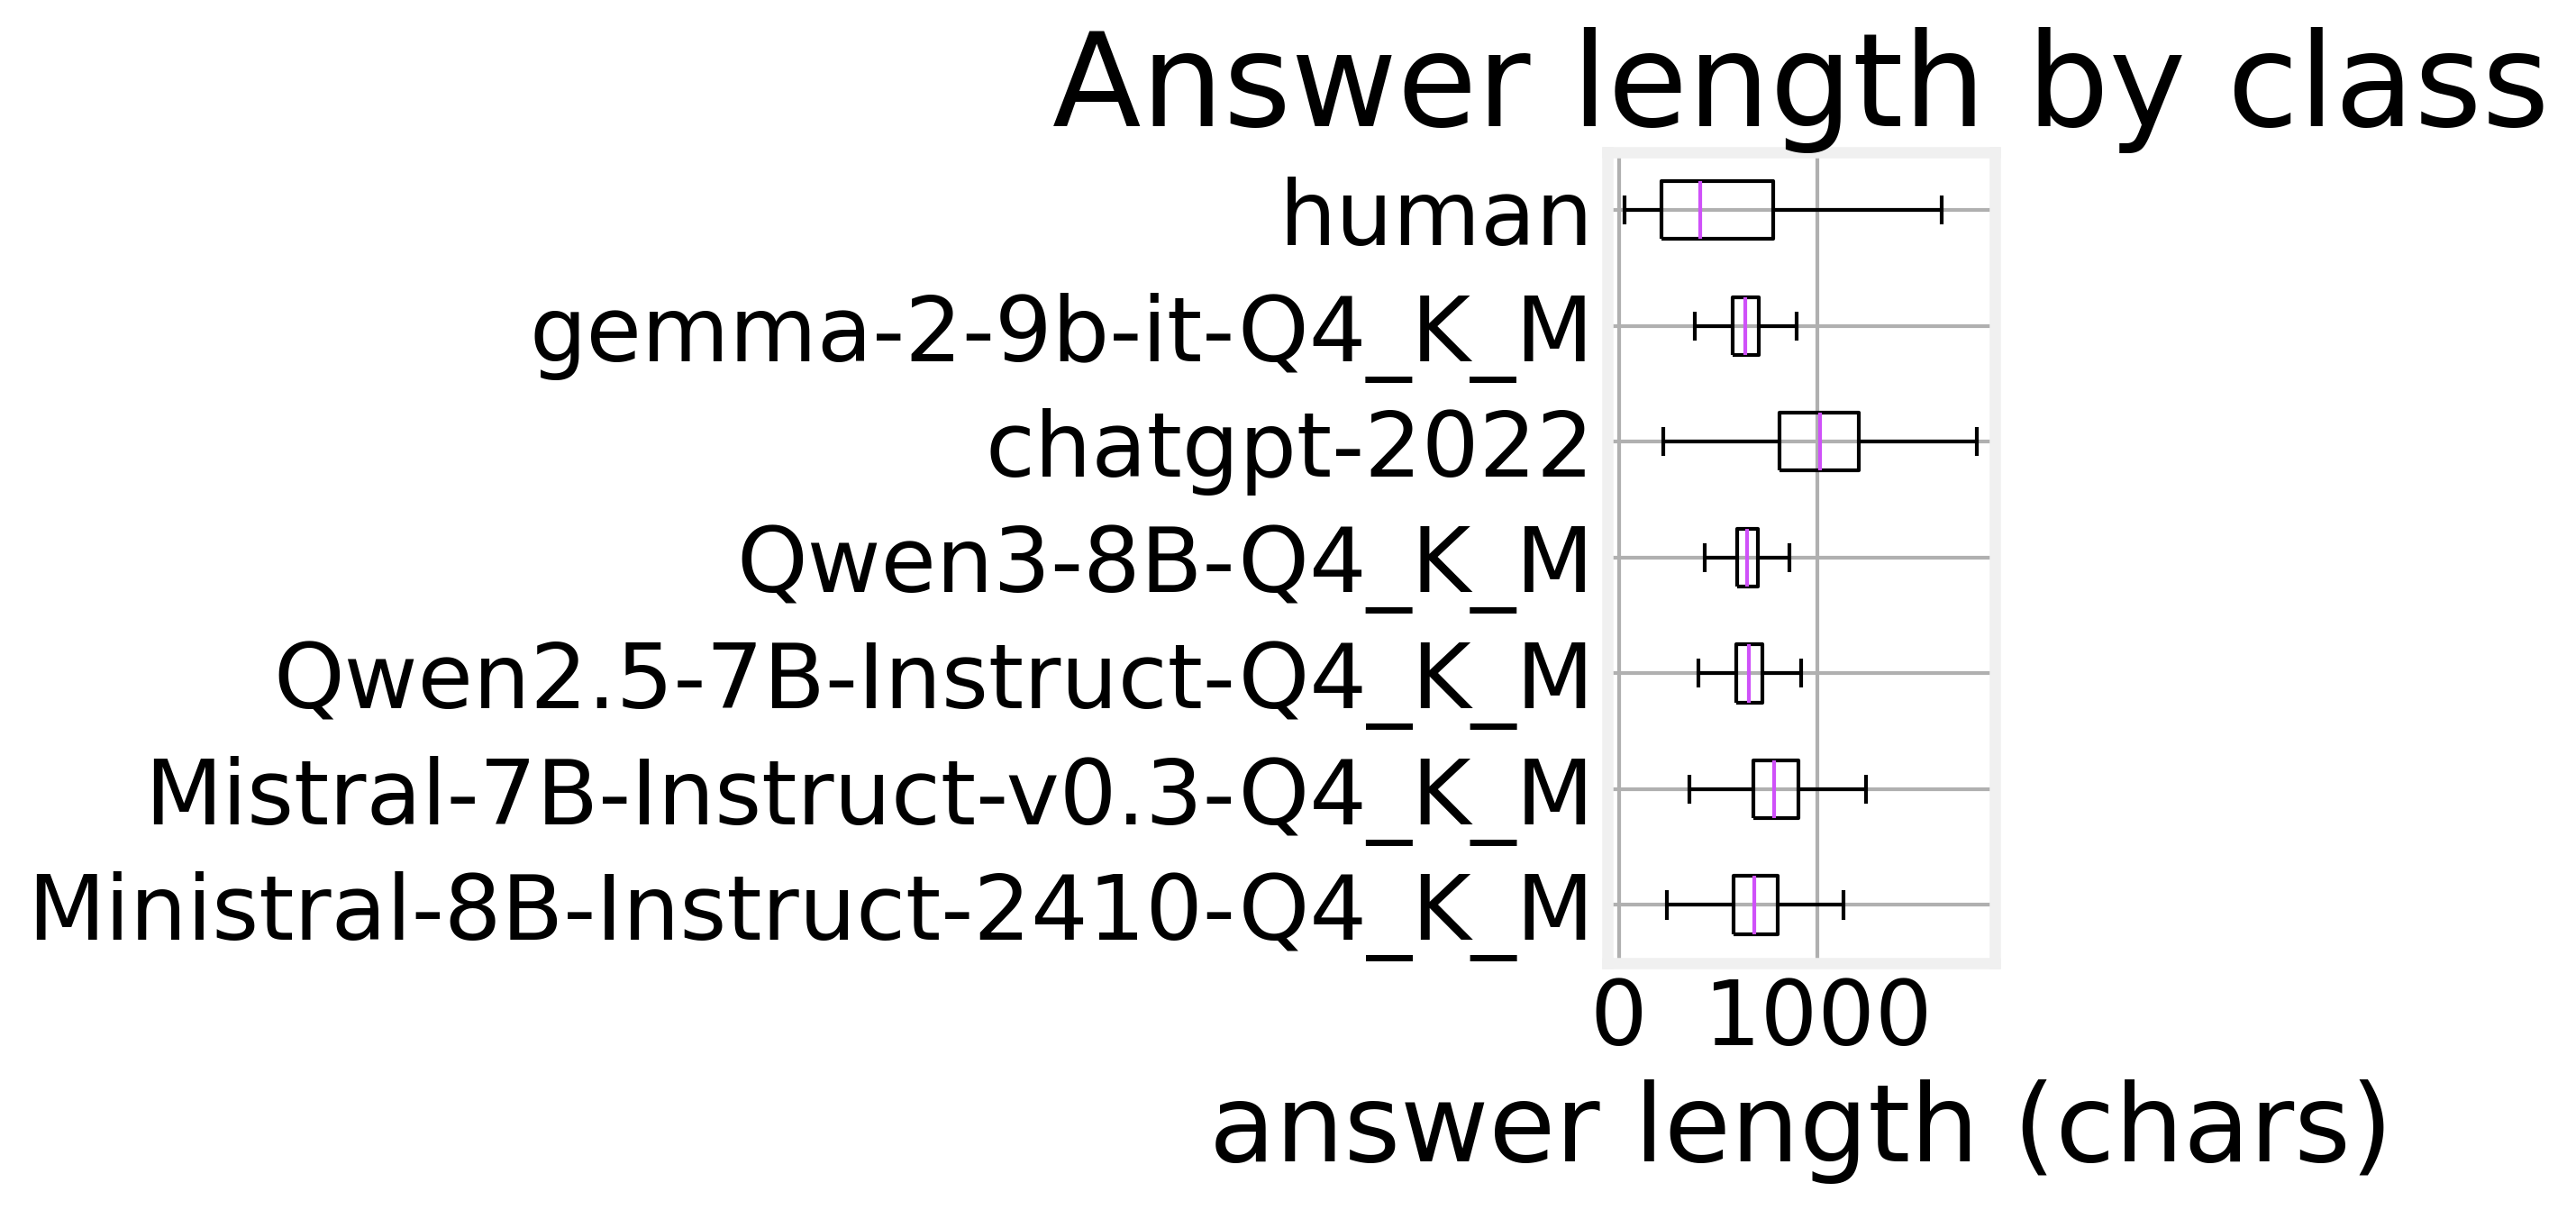

label
Ministral-8B-Instruct-2410-Q4_K_M     682
Mistral-7B-Instruct-v0.3-Q4_K_M       784
Qwen2.5-7B-Instruct-Q4_K_M            656
Qwen3-8B-Q4_K_M                       645
chatgpt-2022                         1011
gemma-2-9b-it-Q4_K_M                  638
human                                 409
Name: median_chars, dtype: int64

In [8]:
# Why length first: if classes separated by answer length alone, every accuracy number
# downstream would be confounded — balancing fixes class counts, not class lengths.
# The instruction asked every model for 4-8 sentences, so heavy overlap is the pass mark.
order_lab = sorted(data.label.unique())
lens = [data.loc[data.label == l, "text"].str.len() for l in order_lab]

fig, ax = plt.subplots(figsize=(8, 0.5 * len(order_lab) + 1.5))
ax.boxplot(lens, vert=False, tick_labels=order_lab, showfliers=False)
ax.set_xlabel("answer length (chars)")
ax.set_title("Answer length by class")
plt.tight_layout()
plt.show()

data.groupby("label").text.apply(
    lambda s: s.str.len().median()).astype(int).rename("median_chars")

In [9]:
# Why one prompt, every author: the classifier's task in miniature — same content,
# seven voices. Pick the first prompt that every class answered.
n_classes = data.label.nunique()
full = data.groupby("prompt_idx").label.nunique()
q_idx = int(full[full == n_classes].index[0])
question = pairs.loc[pairs.prompt_idx == q_idx, "question"].iloc[0]
print(f"prompt {q_idx}: {question[:250]}\n")

for lab in sorted(data.label.unique()):
    txt = data[(data.prompt_idx == q_idx) & (data.label == lab)].text.iloc[0]
    print(f"--- {lab}")
    print(f"    {txt[:280].replace(chr(10), ' ')}\n")

prompt 1: If salt is so bad for cars , why do we use it on the roads ? As the title states , why do we use it ? is there no other option or what ? Please explain like I'm five.

--- Ministral-8B-Instruct-2410-Q4_K_M
    Before we talk about whether salt is bad for cars, let's imagine you're playing with your favorite action figures. When the toys start sliding or becoming difficult to pick up, you might sprinkle it with flour or flour-like white powder to make them stick to the floor, right? The

--- Mistral-7B-Instruct-v0.3-Q4_K_M
    salt, often in the form of rock salt or sodium chloride, is used on roads during winter days to melt ice and snow. This is because when salt comes into contact with freezing temperatures below 0 degrees Celsius (32 degrees Fahrenheit), it transforms from a solid to a liquid. The 

--- Qwen2.5-7B-Instruct-Q4_K_M
    Imagine it's a cold winter day and the roads are covered in ice, making it hard for cars to drive safely. Salt helps to melt this ice and sno

In [10]:
# Why these markers: each is a habit a human reader would cite when guessing the
# author, and each is cheap to count. Rates per 1,000 characters keep classes of
# different verbosity comparable. After the detokenization repair, the human column
# has to stand out on real habits — contractions, first person — not on spacing.
patterns = {
    "contractions": r"\w['’]\w",
    "first person": r"\b[Ii]\b",
    "exclamations": r"!",
    "questions":    r"\?",
    "em-dashes":    r"—",
    "quotes":       r'"',
    "newlines":     r"\n",
}
counts = pd.DataFrame({name: data.text.str.count(pat)
                       for name, pat in patterns.items()})
counts["chars"] = data.text.str.len()
counts["label"] = data.label.values

sums = counts.groupby("label").sum()
rates = (sums[list(patterns)].div(sums.chars, axis=0) * 1000).round(2)
rates

,contractions,first person,exclamations,questions,em-dashes,quotes,newlines
label,,,,,,,
Ministral-8B-Instruct-2410-Q4_K_M,5.28,0.08,0.76,0.18,0.05,1.32,0.14
Mistral-7B-Instruct-v0.3-Q4_K_M,3.78,0.05,0.59,0.05,0.03,1.10,0.61
Qwen2.5-7B-Instruct-Q4_K_M,5.36,0.05,0.60,0.06,0.08,1.12,0.01
Qwen3-8B-Q4_K_M,6.15,0.06,0.29,0.03,0.65,1.20,0.03
chatgpt-2022,1.50,0.16,0.20,0.07,0.00,1.06,1.31
gemma-2-9b-it-Q4_K_M,5.12,0.04,1.77,0.16,0.02,1.43,0.62
human,3.32,1.11,0.16,0.34,0.02,1.50,0.00


## Split by prompt, never by completion

Every downstream number in this notebook comes from this split. The detector fits on train prompts and every chart reads from held-out test prompts, except the train bars shown for the generalization gap.

In [11]:
# Why modulo on prompt_idx: the same prompts feed every class in the same order,
# so this one rule puts a prompt on one side of the split for all classes at once.
test_mask = data.prompt_idx % TEST_MOD == 0
train, test = data[~test_mask].copy(), data[test_mask].copy()
print(f"train: {len(train):,} rows on {train.prompt_idx.nunique():,} prompts | "
      f"test: {len(test):,} rows on {test.prompt_idx.nunique():,} prompts")

train: 53,649 rows on 7,996 prompts | test: 13,558 rows on 2,000 prompts


## Train the detector: fine-tune ModernBERT

One classification head on `answerdotai/ModernBERT-base`, trained on the prompt-level split. Three epochs at `2e-5` is the standard fine-tuning recipe for an encoder this size; the eval pass at each epoch end watches for the test score rolling over, the sign that a shorter schedule would do.

The trained checkpoint lands in `RESULTS_DIR/detector_modernbert`, and the cell skips training when a cached checkpoint with the same class list is already there. A new generation run changes the class list, which invalidates the cache automatically; a change that leaves the classes alone but alters the text — like the detokenization repair — needs a manual `rm -r` of the folder.

In [12]:
mb_dir = Path(RESULTS_DIR) / "detector_modernbert"

# Why compare label sets, not just existence: new models in the JSONL become new
# classes, and a checkpoint trained on the old class list would misscore them all.
def cached_label_set(d):
    if not (d / "model.safetensors").exists() or not (d / "config.json").exists():
        return None
    return sorted(json.load(open(d / "config.json")).get("label2id", {}))

if cached_label_set(mb_dir) == sorted(data.label.unique()):
    print(f"cached ModernBERT found in {mb_dir}, same classes — skipping training "
          "(delete the folder to force a retrain)")
else:
    if torch.cuda.is_available():
        DEVICE, BS = "cuda", 32
    elif torch.backends.mps.is_available():
        DEVICE, BS = "mps", 8
    else:
        DEVICE, BS = "cpu", 4

    labels_list = sorted(data.label.unique())
    l2i = {l: i for i, l in enumerate(labels_list)}

    tok = AutoTokenizer.from_pretrained(TRF_MODEL)

    def enc(batch):
        out = tok(batch["text"], truncation=True, max_length=MAX_LEN)
        out["labels"] = [l2i[l] for l in batch["label"]]
        return out

    # Why remove_columns: the collator tensorizes every surviving column, and the raw
    # string label crashes it — only the tokenized fields and integer labels may remain.
    ds_tr = Dataset.from_pandas(train[["text", "label"]], preserve_index=False).map(
        enc, batched=True, remove_columns=["text", "label"])
    ds_te = Dataset.from_pandas(test[["text", "label"]], preserve_index=False).map(
        enc, batched=True, remove_columns=["text", "label"])

    # id2label rides in the checkpoint so a fresh session can score without this cell.
    model = AutoModelForSequenceClassification.from_pretrained(
        TRF_MODEL, num_labels=len(labels_list),
        id2label={i: l for l, i in l2i.items()}, label2id=l2i)

    def metrics_fn(p):
        y = np.argmax(p.predictions, axis=1)
        return {"accuracy": accuracy_score(p.label_ids, y),
                "macro_f1": f1_score(p.label_ids, y, average="macro")}

    args = TrainingArguments(
        output_dir=str(mb_dir),
        per_device_train_batch_size=BS,
        per_device_eval_batch_size=BS * 2,
        num_train_epochs=TRF_EPOCHS,
        learning_rate=2e-5,
        bf16=(DEVICE == "cuda"),
        eval_strategy="epoch",
        save_strategy="no",
        logging_steps=50,
        seed=SEED,
        report_to="none",
    )
    # Why an explicit collator: enc tokenizes without padding, so batches hold ragged
    # sequences the default collator cannot tensorize — this one pads per batch.
    trainer = Trainer(model=model, args=args, train_dataset=ds_tr,
                      eval_dataset=ds_te, compute_metrics=metrics_fn,
                      data_collator=DataCollatorWithPadding(tok))
    trainer.train()
    trainer.save_model(str(mb_dir))
    tok.save_pretrained(str(mb_dir))
    # Why predict instead of evaluate: transformers 5.x closes the train lifecycle when
    # train() returns, and a standalone evaluate() trips its callback guard. predict()
    # runs the same compute_metrics without touching that state.
    print(trainer.predict(ds_te).metrics)

cached ModernBERT found in results_new/detector_modernbert, same classes — skipping training (delete the folder to force a retrain)


## Score the held-out prompts

The detector reloads from disk before it scores anything — the analysis must be reproducible in a fresh session, and the saved checkpoint carries its own label map in `id2label`, so nothing here depends on training-cell state. The train rows get scored once too, for the generalization gap panel; every other view reads test only.

In [13]:
assert (mb_dir / "model.safetensors").exists(), "no checkpoint, run the training cell"

dev = ("cuda" if torch.cuda.is_available()
       else "mps" if torch.backends.mps.is_available() else "cpu")
tok_mb = AutoTokenizer.from_pretrained(mb_dir)
model_mb = AutoModelForSequenceClassification.from_pretrained(mb_dir).to(dev).eval()
classes_arr = np.array([model_mb.config.id2label[i]
                        for i in range(model_mb.config.num_labels)])

def score_texts(texts, bs=128):
    probs = []
    for i in range(0, len(texts), bs):
        enc_b = tok_mb(texts[i:i + bs], truncation=True, max_length=MAX_LEN,
                       padding=True, return_tensors="pt").to(dev)
        with torch.no_grad():
            logits = model_mb(**enc_b).logits
        probs.append(torch.softmax(logits.float(), dim=1).cpu().numpy())
    return np.vstack(probs)

t0 = time.time()
P = score_texts(test.text.tolist())
pred = classes_arr[P.argmax(1)]
acc = accuracy_score(test.label, pred)
macro = f1_score(test.label, pred, average="macro")
print(f"scored {len(test):,} test rows in {time.time() - t0:.0f} s on {dev} | "
      f"accuracy {acc:.3f} | macro F1 {macro:.3f}\n")
print(classification_report(test.label, pred, digits=3))

# Why score train too: the gap between train and test is the overfit measure.
# One pass here, read by the gap panel below, never recomputed.
pred_train = classes_arr[score_texts(train.text.tolist()).argmax(1)]
acc_tr = accuracy_score(train.label, pred_train)
macro_tr = f1_score(train.label, pred_train, average="macro")

Loading weights:   0%|          | 0/138 [00:00<?, ?it/s]

scored 13,558 test rows in 100 s on cuda | accuracy 0.941 | macro F1 0.941

                                   precision    recall  f1-score   support

Ministral-8B-Instruct-2410-Q4_K_M      0.848     0.846     0.847      1936
  Mistral-7B-Instruct-v0.3-Q4_K_M      0.878     0.893     0.885      1936
       Qwen2.5-7B-Instruct-Q4_K_M      0.935     0.932     0.934      1936
                  Qwen3-8B-Q4_K_M      0.956     0.973     0.964      1936
                     chatgpt-2022      0.993     0.988     0.990      1922
             gemma-2-9b-it-Q4_K_M      0.983     0.962     0.972      1936
                            human      0.995     0.992     0.993      1956

                         accuracy                          0.941     13558
                        macro avg      0.941     0.941     0.941     13558
                     weighted avg      0.941     0.941     0.941     13558



## Analyze the results

Eight views, all on the prompt-level split: the generalization gap, per-class F1, the confusion matrix, accuracy by length and by domain, confidence and reliability, top-k accuracy, the per-class domain heatmap, and the detector's own embedding geometry. Train bars appear once, in the gap panel. Everything after that reads test only.

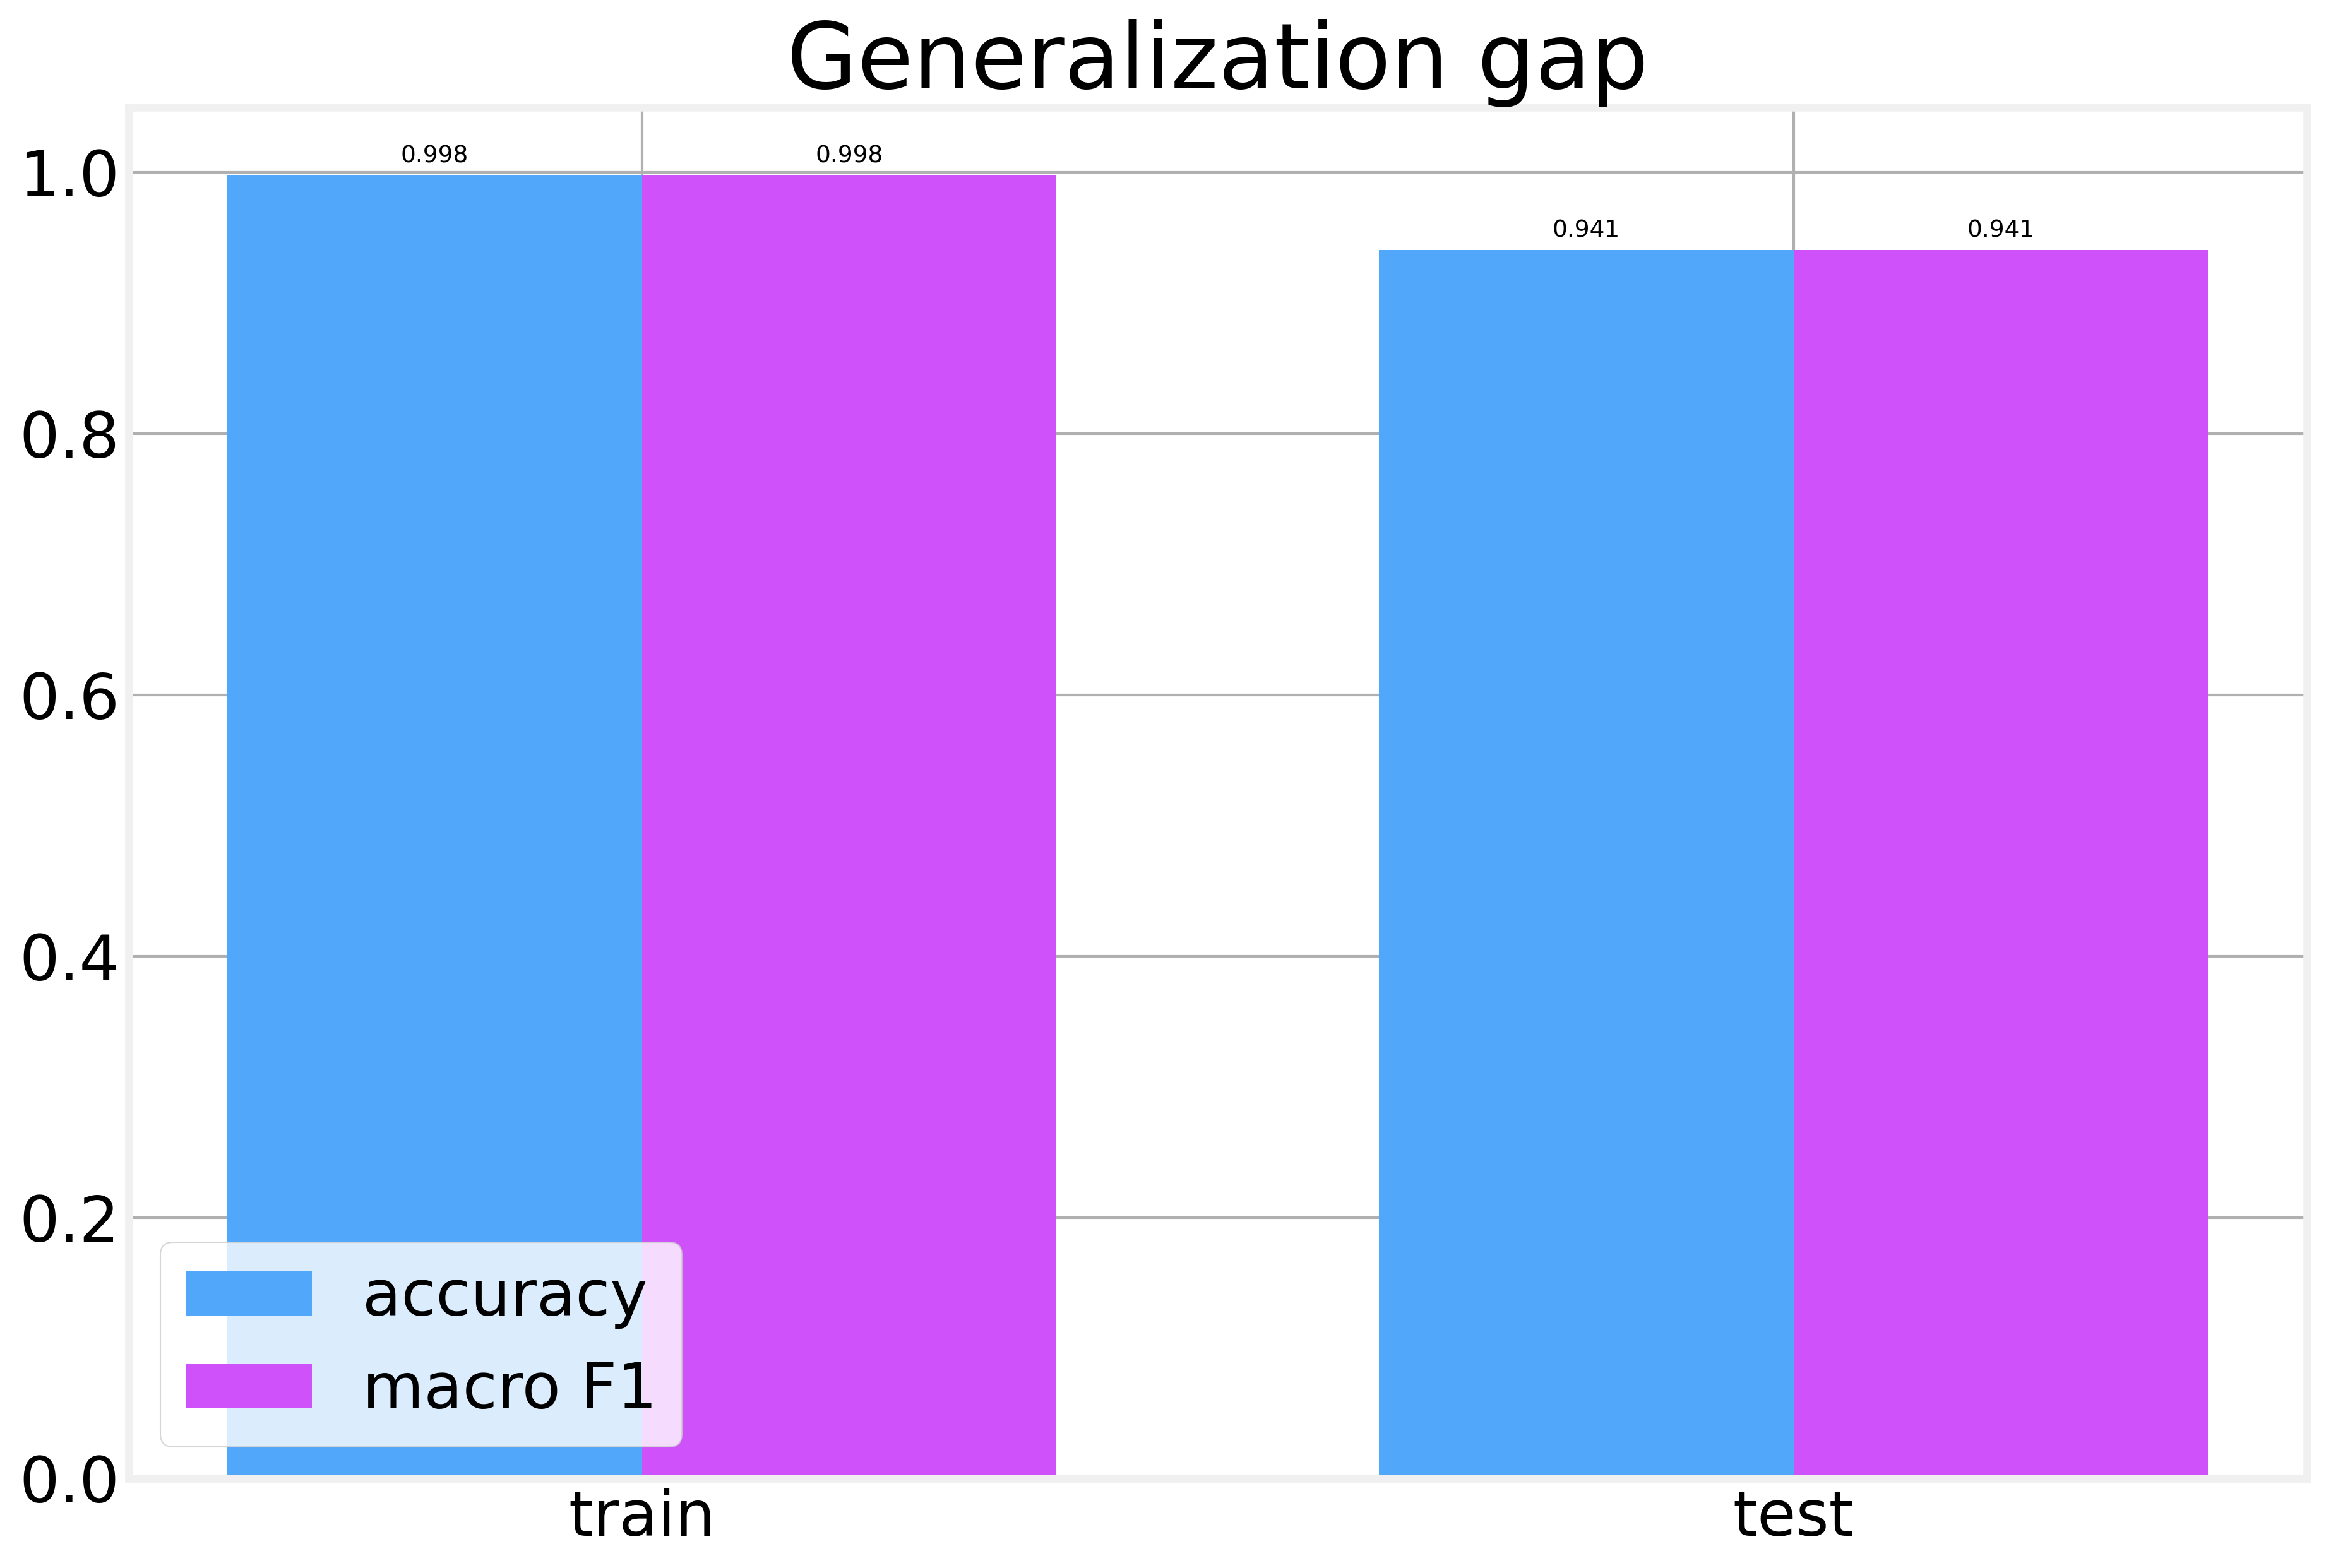

accuracy gap: +0.057 | macro F1 gap: +0.057


In [14]:
# Why one chart for the gap: train far above test means memorized prompts, and nothing
# downstream matters until it closes. The scores come from the scoring cell above.
fig, ax = plt.subplots()
x = np.arange(2)
ax.bar(x - 0.18, [acc_tr, acc], width=0.36, color=colors[0], label="accuracy")
ax.bar(x + 0.18, [macro_tr, macro], width=0.36, color=colors[1], label="macro F1")
ax.set_xticks(x)
ax.set_xticklabels(["train", "test"])
ax.set_ylim(0, 1.05)
ax.set_title("Generalization gap")
for xi, v in zip([-0.18, 0.82, 0.18, 1.18], [acc_tr, acc, macro_tr, macro]):
    ax.text(xi, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()
print(f"accuracy gap: {acc_tr - acc:+.3f} | macro F1 gap: {macro_tr - macro:+.3f}")

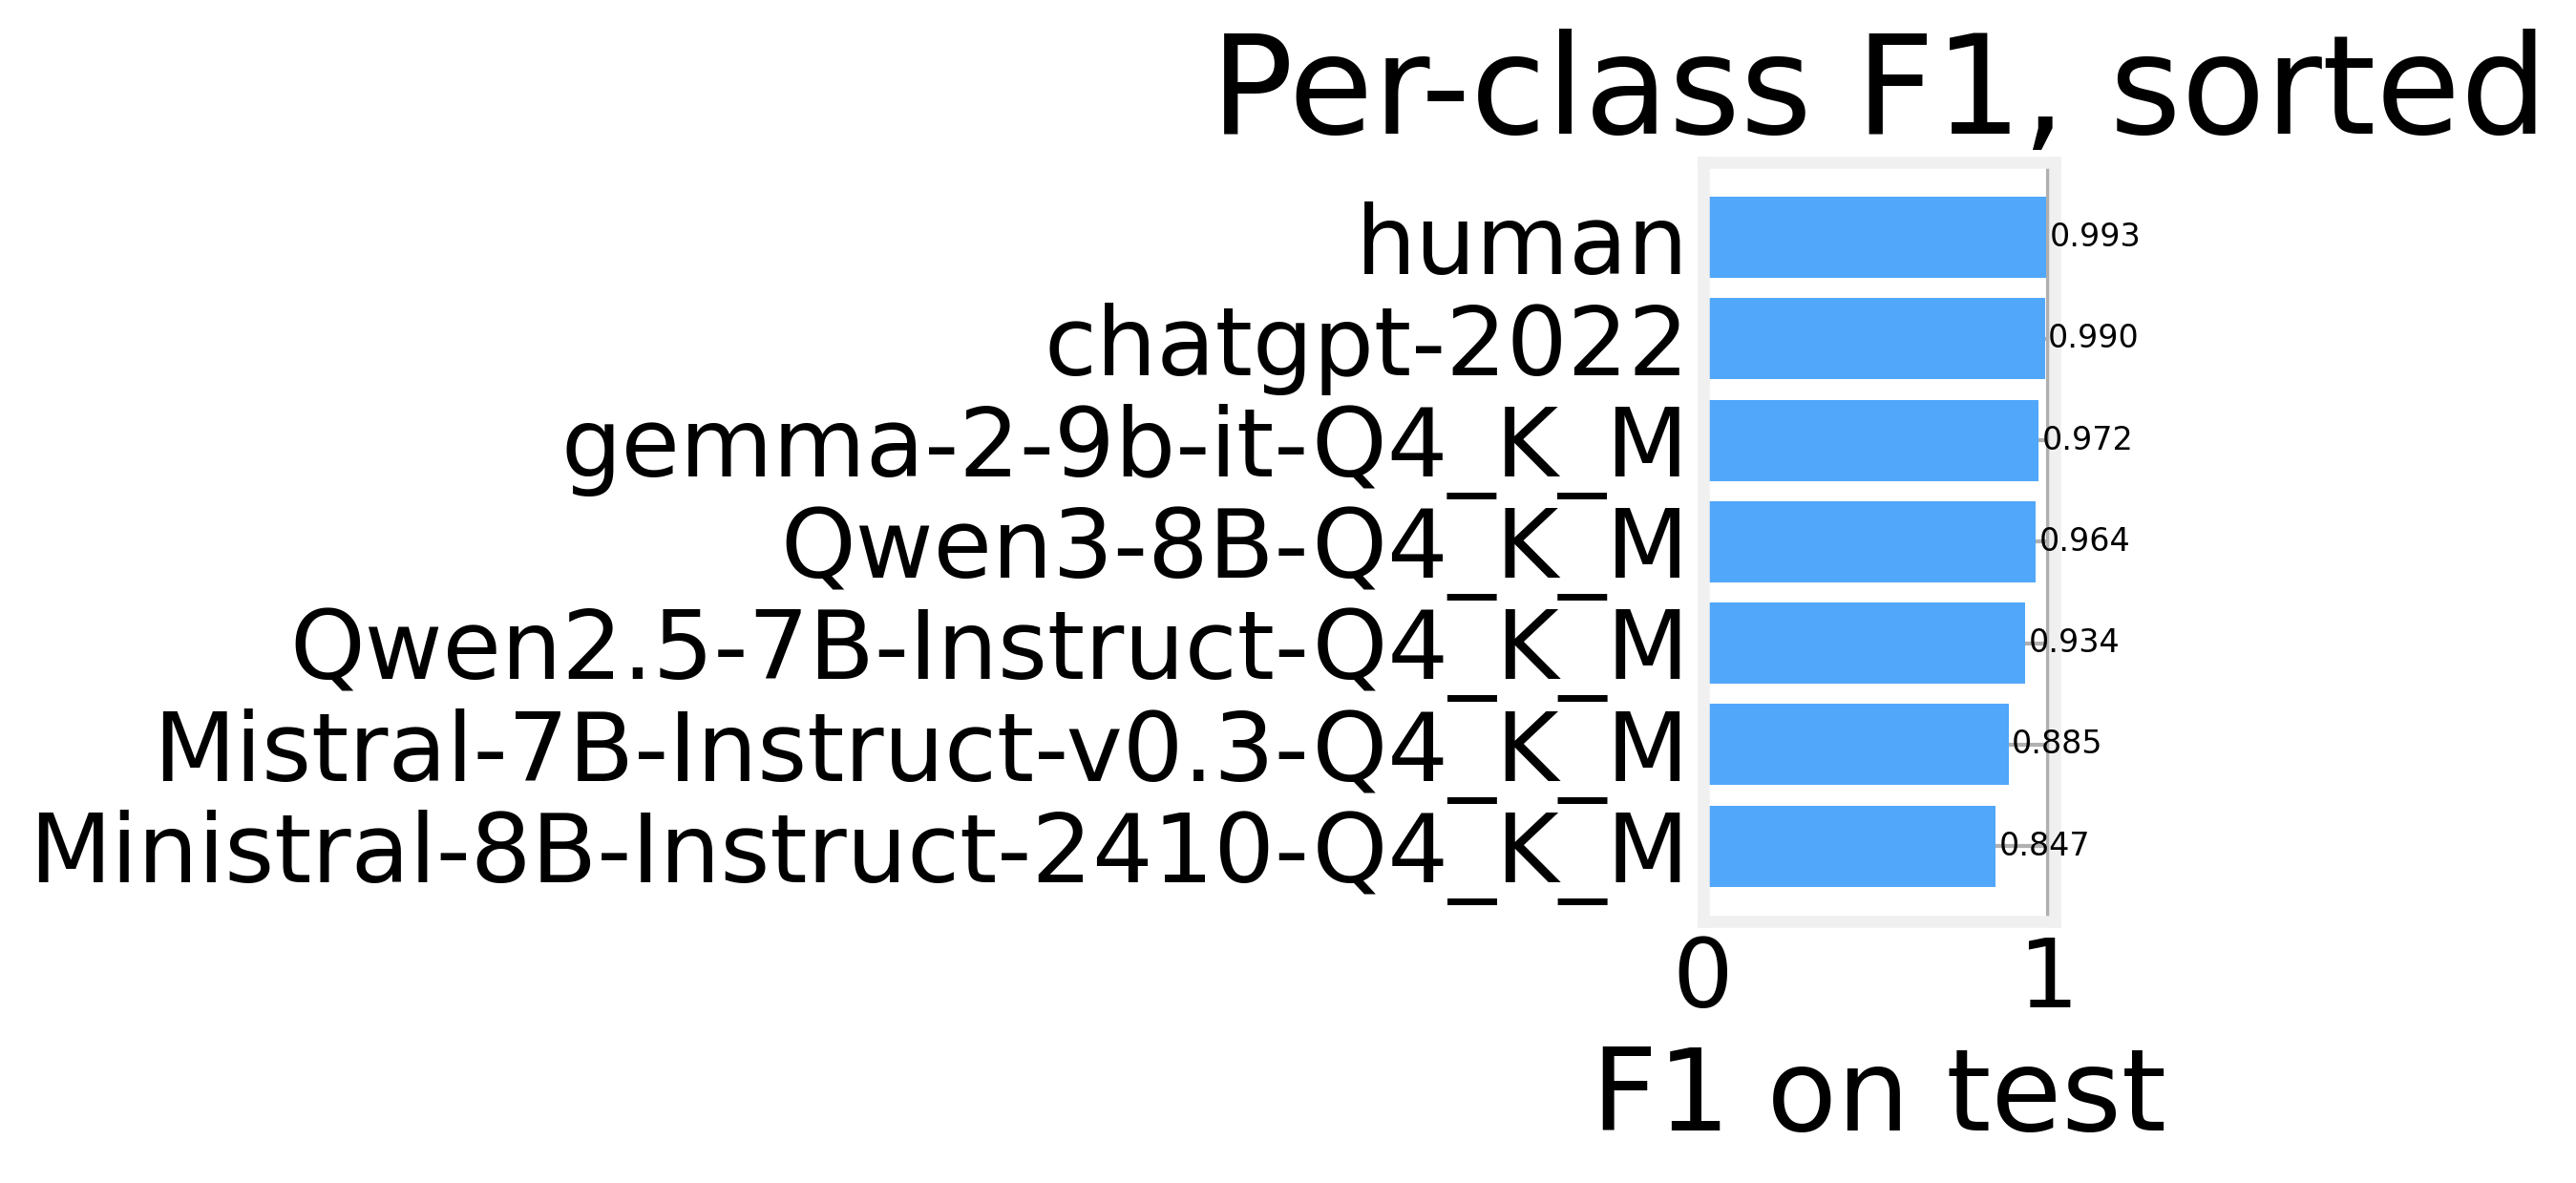

In [15]:
# Why per-class F1: the average hides the one class the detector cannot see.
rep = classification_report(test.label, pred, output_dict=True)
per_class = (pd.DataFrame(rep).T
             .loc[sorted(test.label.unique()), ["precision", "recall", "f1-score"]]
             .sort_values("f1-score"))

fig, ax = plt.subplots(figsize=(8, 0.45 * len(per_class) + 1.5))
ax.barh(per_class.index, per_class["f1-score"], color=colors[0])
ax.set_xlim(0, 1.02)
ax.set_xlabel("F1 on test")
ax.set_title("Per-class F1, sorted")
for i, v in enumerate(per_class["f1-score"]):
    ax.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

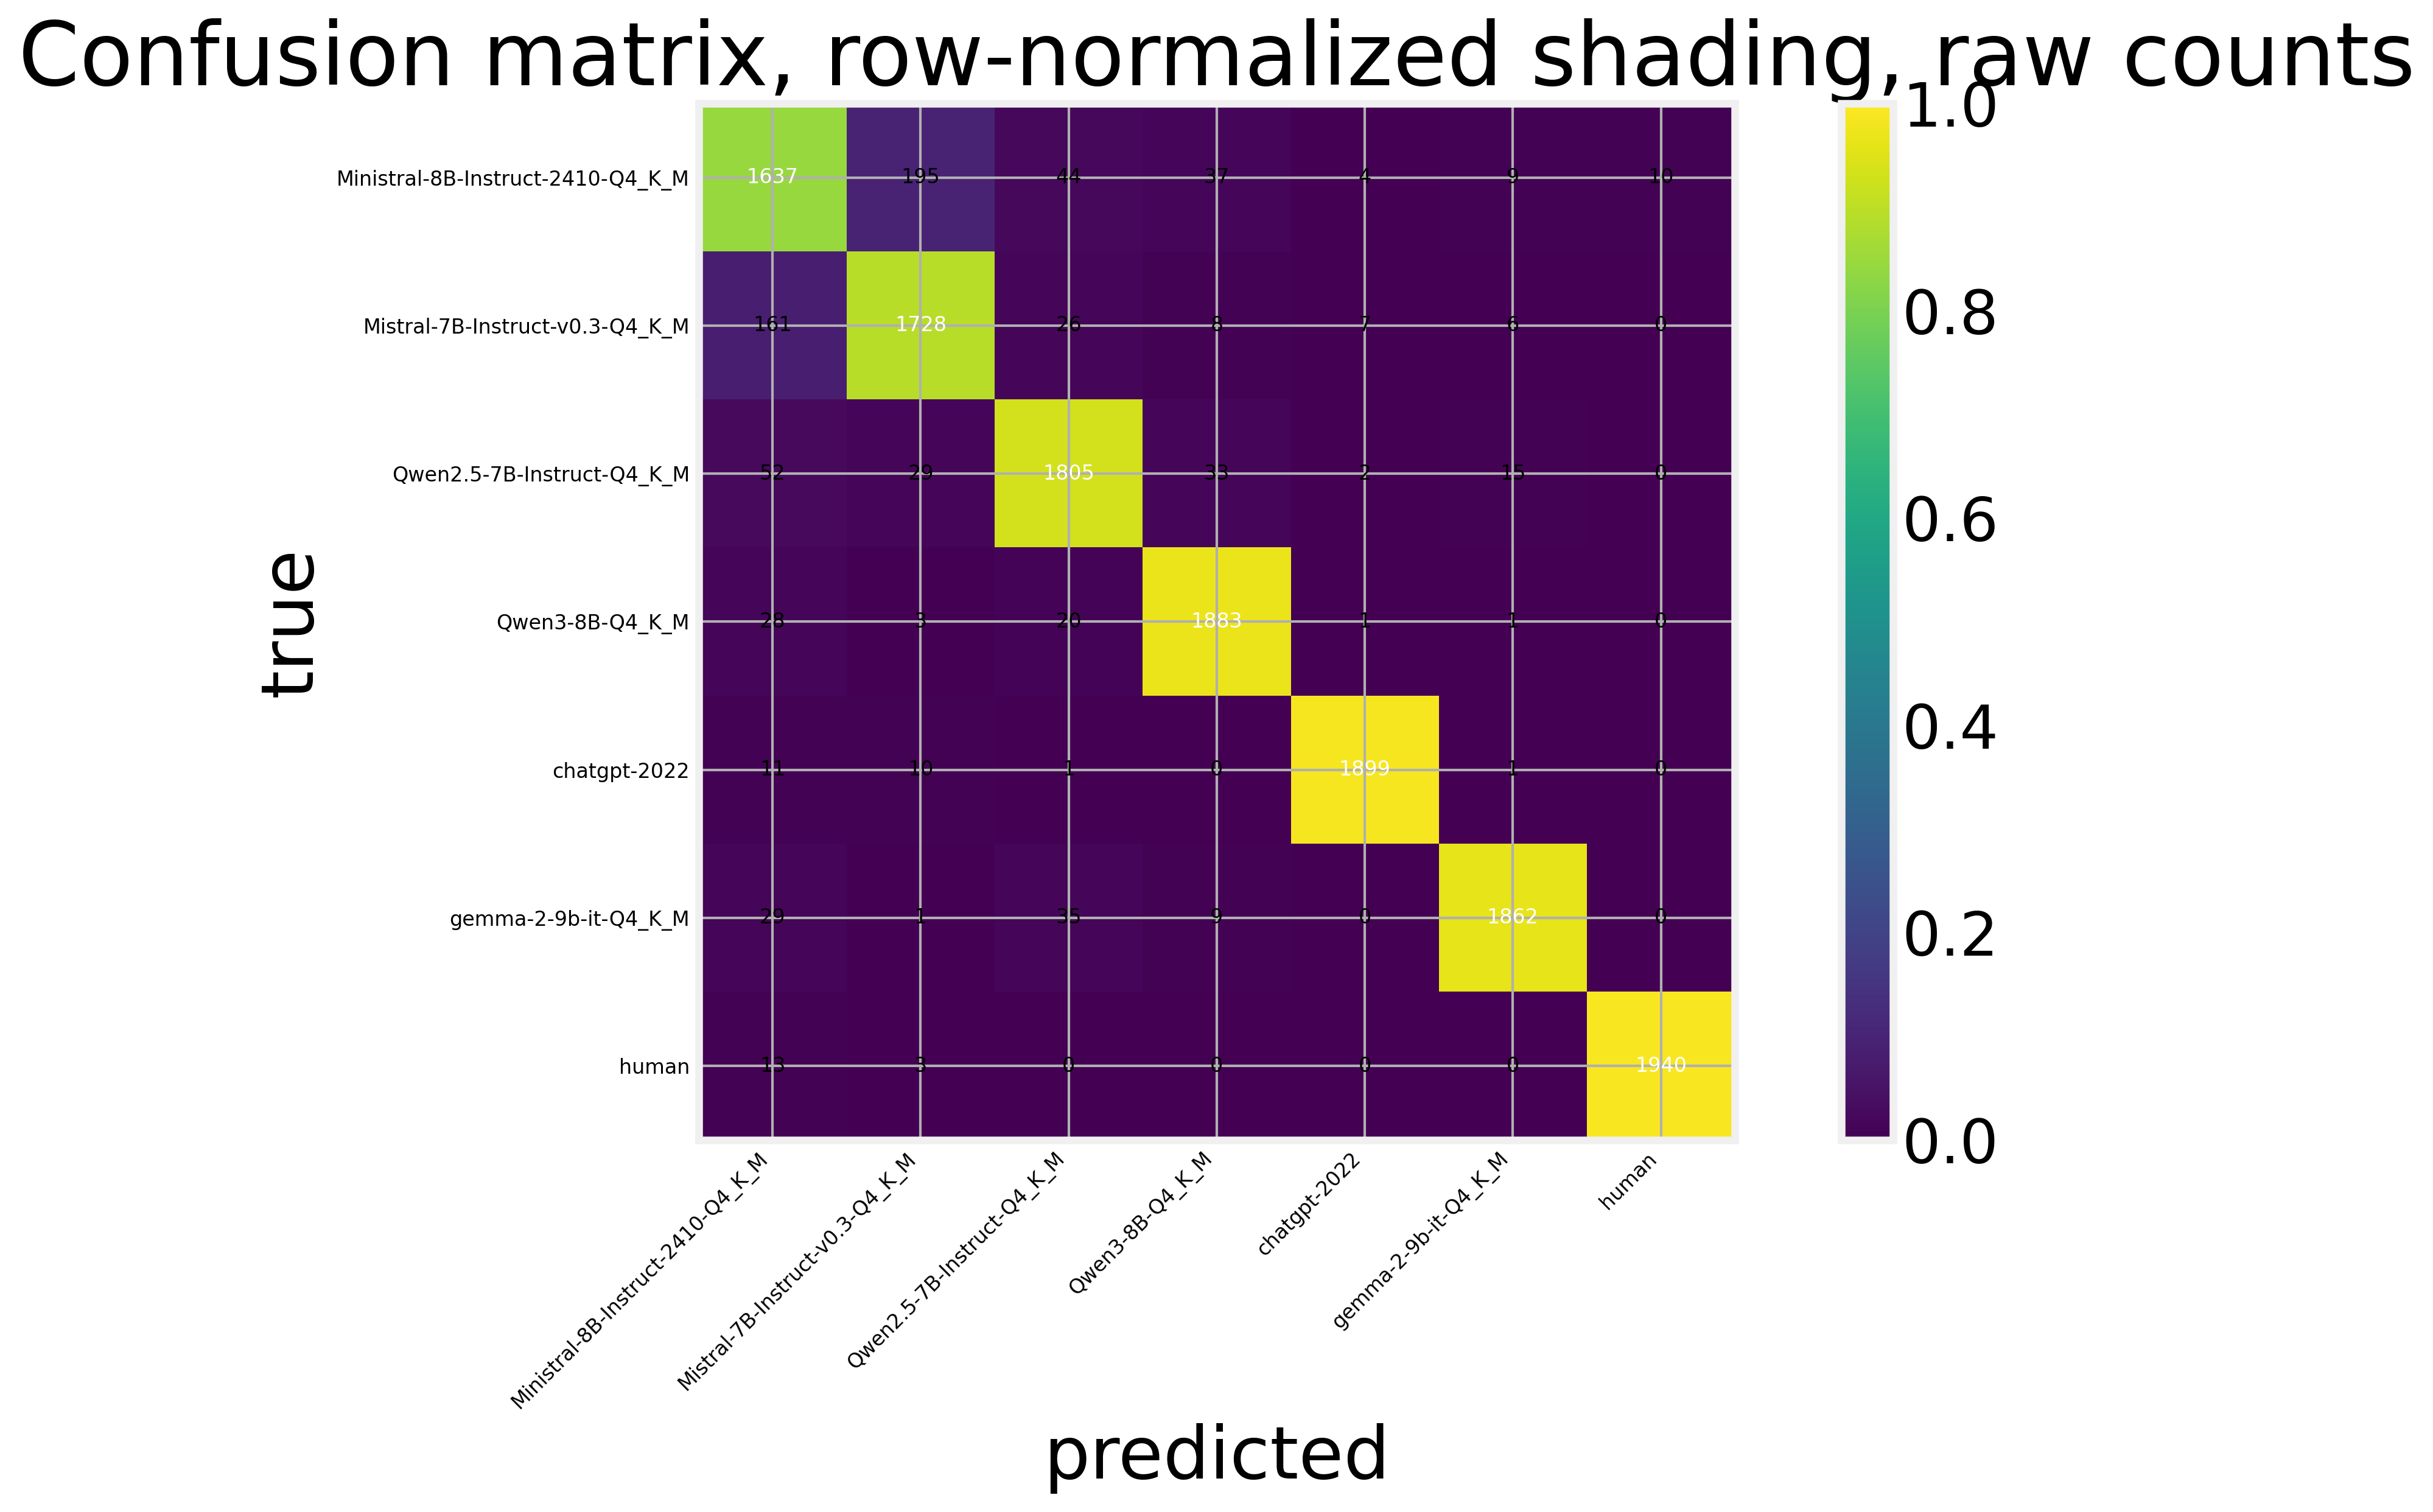

top confused pairs, true -> predicted:
  Ministral-8B-Instruct-2410-Q4_K_M -> Mistral-7B-Instruct-v0.3-Q4_K_M: 195
  Mistral-7B-Instruct-v0.3-Q4_K_M -> Ministral-8B-Instruct-2410-Q4_K_M: 161
  Qwen2.5-7B-Instruct-Q4_K_M -> Ministral-8B-Instruct-2410-Q4_K_M: 52
  Ministral-8B-Instruct-2410-Q4_K_M -> Qwen2.5-7B-Instruct-Q4_K_M: 44
  Ministral-8B-Instruct-2410-Q4_K_M -> Qwen3-8B-Q4_K_M: 37


In [16]:
# Why row-normalized colors with raw counts: shades compare classes fairly, numbers stay auditable.
labels_sorted = sorted(data.label.unique())
cm = confusion_matrix(test.label, pred, labels=labels_sorted)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots()
im = ax.imshow(cm_norm, vmin=0, vmax=1)
ax.set_xticks(range(len(labels_sorted)))
ax.set_yticks(range(len(labels_sorted)))
ax.set_xticklabels(labels_sorted, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(labels_sorted, fontsize=8)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
ax.set_title("Confusion matrix, row-normalized shading, raw counts")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm_norm[i, j] > 0.5 else "black", fontsize=8)
fig.colorbar(im, fraction=0.046)
plt.tight_layout()
plt.show()

off = cm.astype(float).copy()
np.fill_diagonal(off, 0)
flat = [(labels_sorted[i], labels_sorted[j], int(off[i, j]))
        for i in range(len(labels_sorted)) for j in range(len(labels_sorted)) if off[i, j] > 0]
print("top confused pairs, true -> predicted:")
for a, b, n in sorted(flat, key=lambda x: -x[2])[:5]:
    print(f"  {a} -> {b}: {n}")

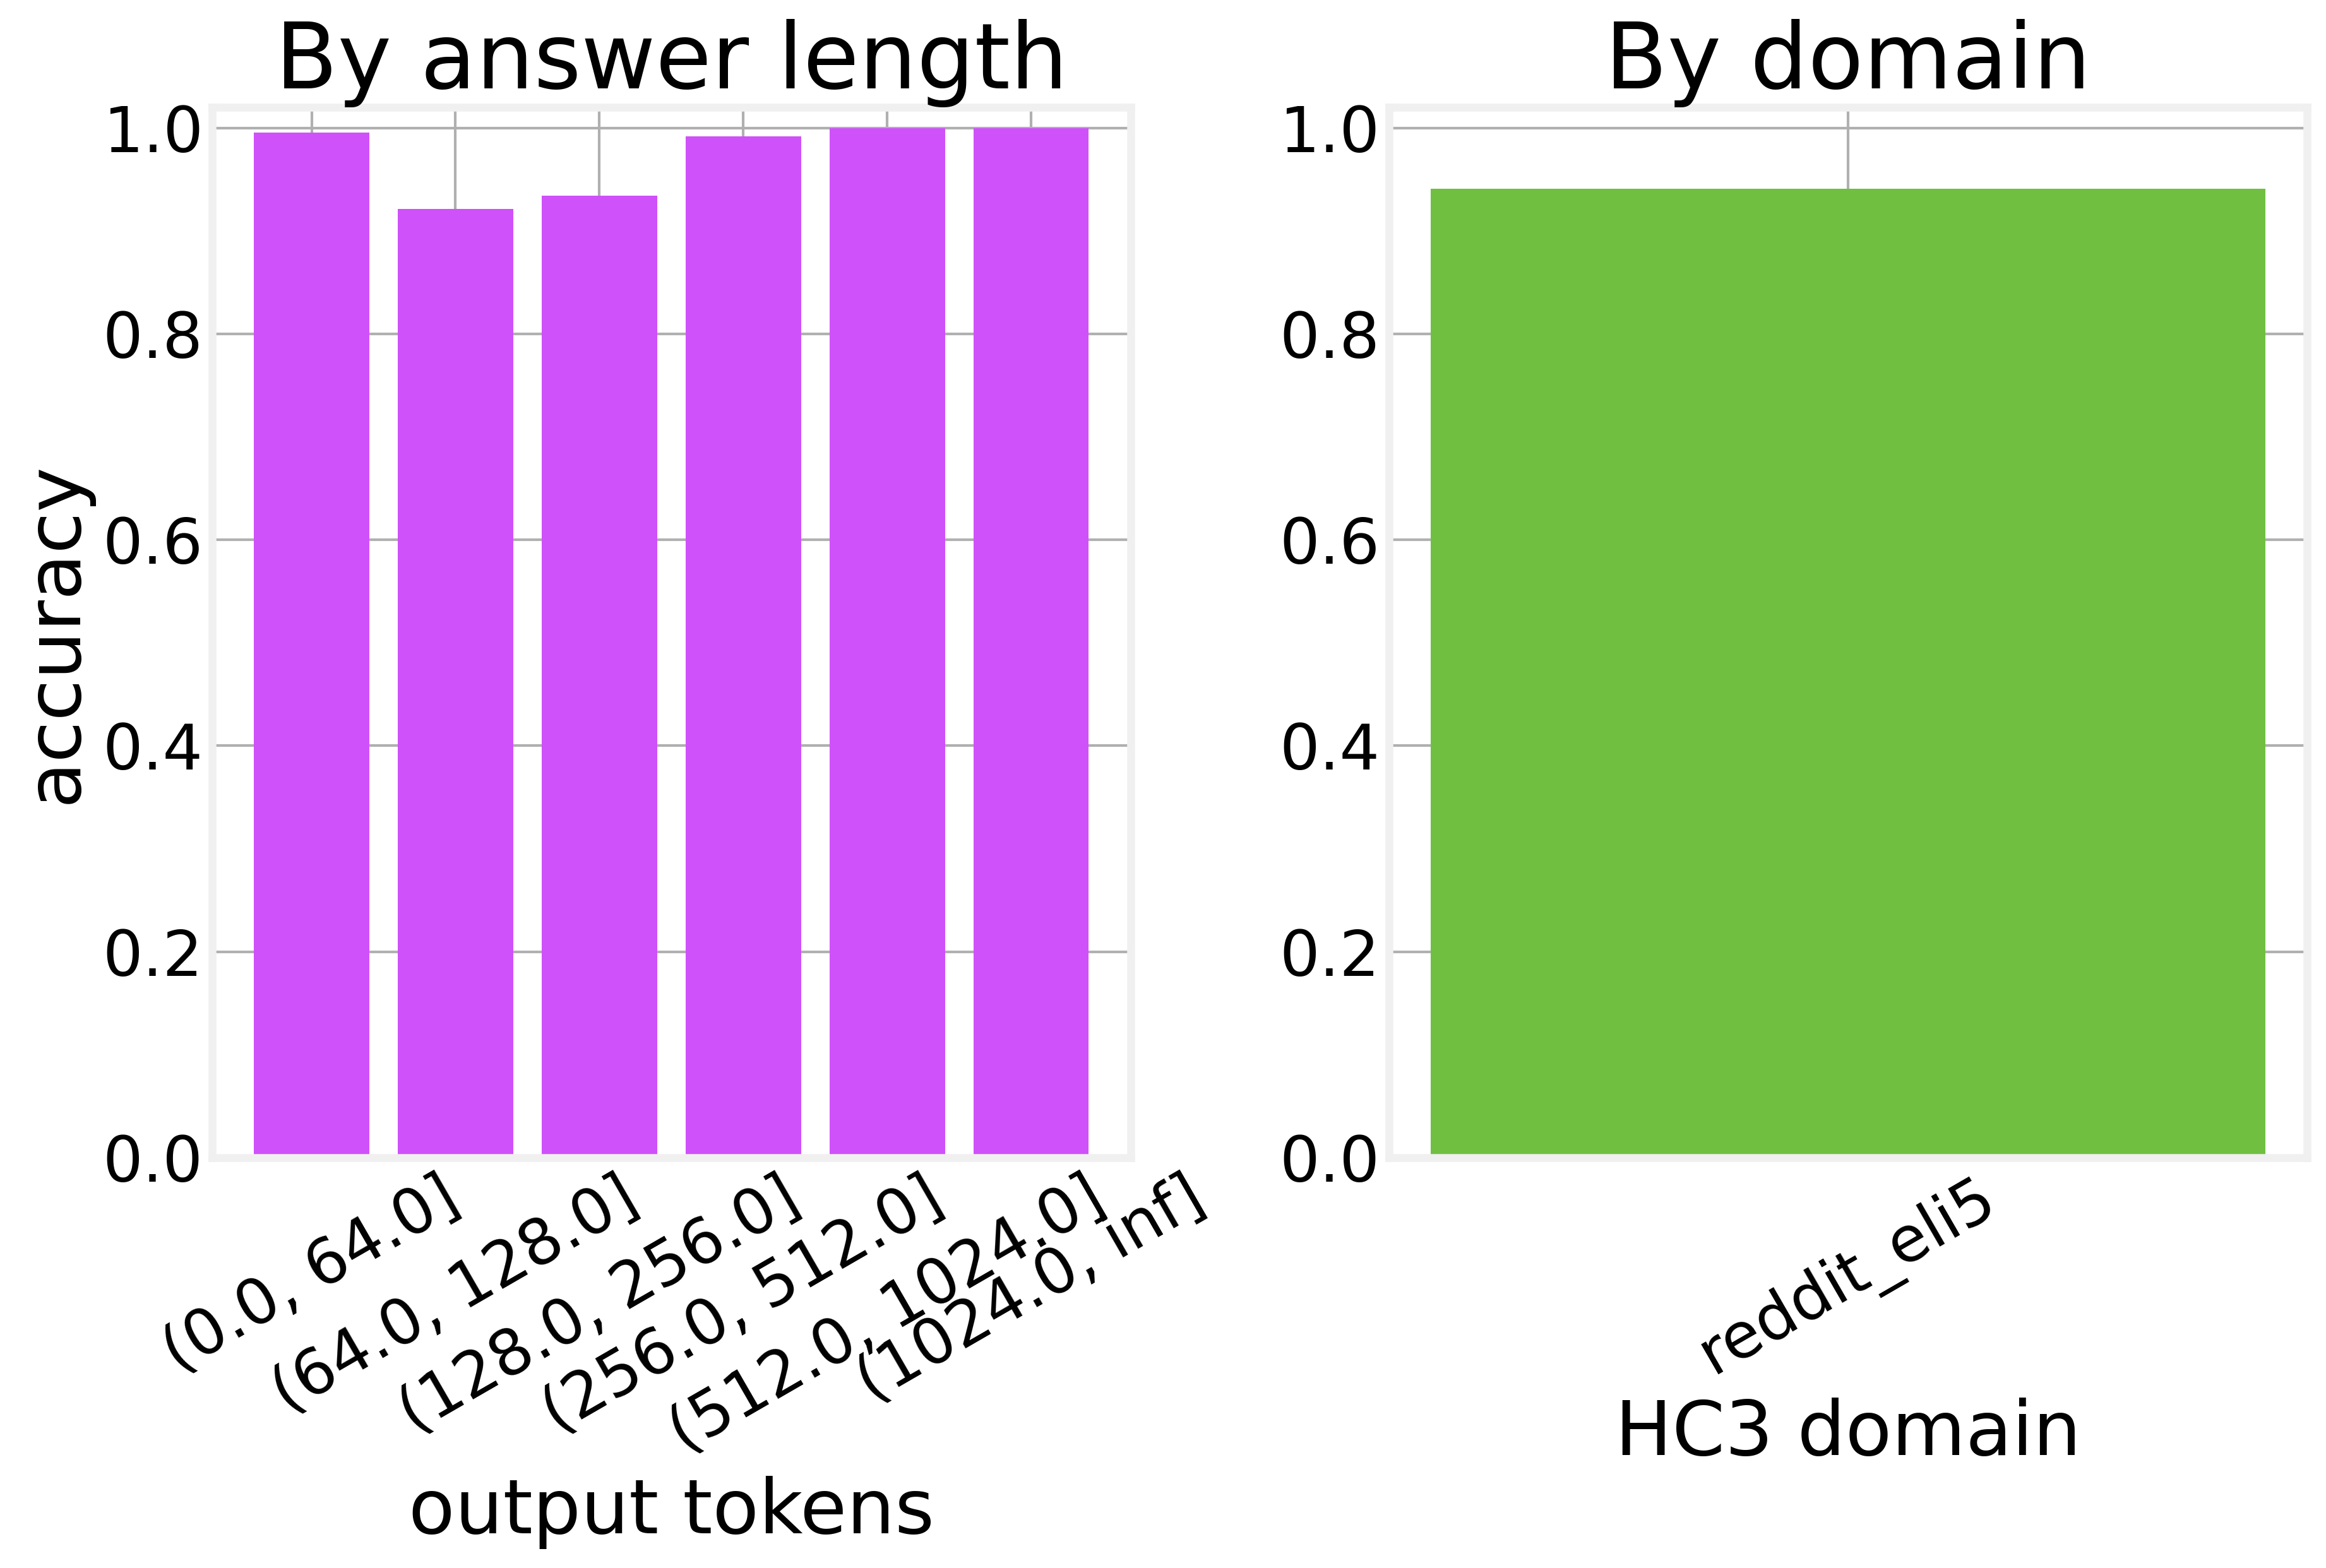

In [17]:
test_res = test.assign(pred=pred, correct=lambda d: d.pred == d.label)

# Why two slices: length moves evidence, domain moves register. Every model ran at its
# own fixed default sampling, so there is no temperature axis to slice anymore.
bins = pd.cut(test_res.out_tokens, [0, 64, 128, 256, 512, 1024, np.inf])
by_len = test_res.groupby(bins, observed=True).correct.mean()
by_dom = test_res.groupby("domain").correct.mean().sort_values()

fig, axes = plt.subplots(1, 2)
axes[0].bar([str(b) for b in by_len.index], by_len.values, color=colors[1])
axes[0].set_xlabel("output tokens")
axes[0].set_ylabel("accuracy")
axes[0].set_title("By answer length")
axes[0].set_ylim(0, 1.02)
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(by_dom.index, by_dom.values, color=colors[2])
axes[1].set_xlabel("HC3 domain")
axes[1].set_title("By domain")
axes[1].set_ylim(0, 1.02)
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

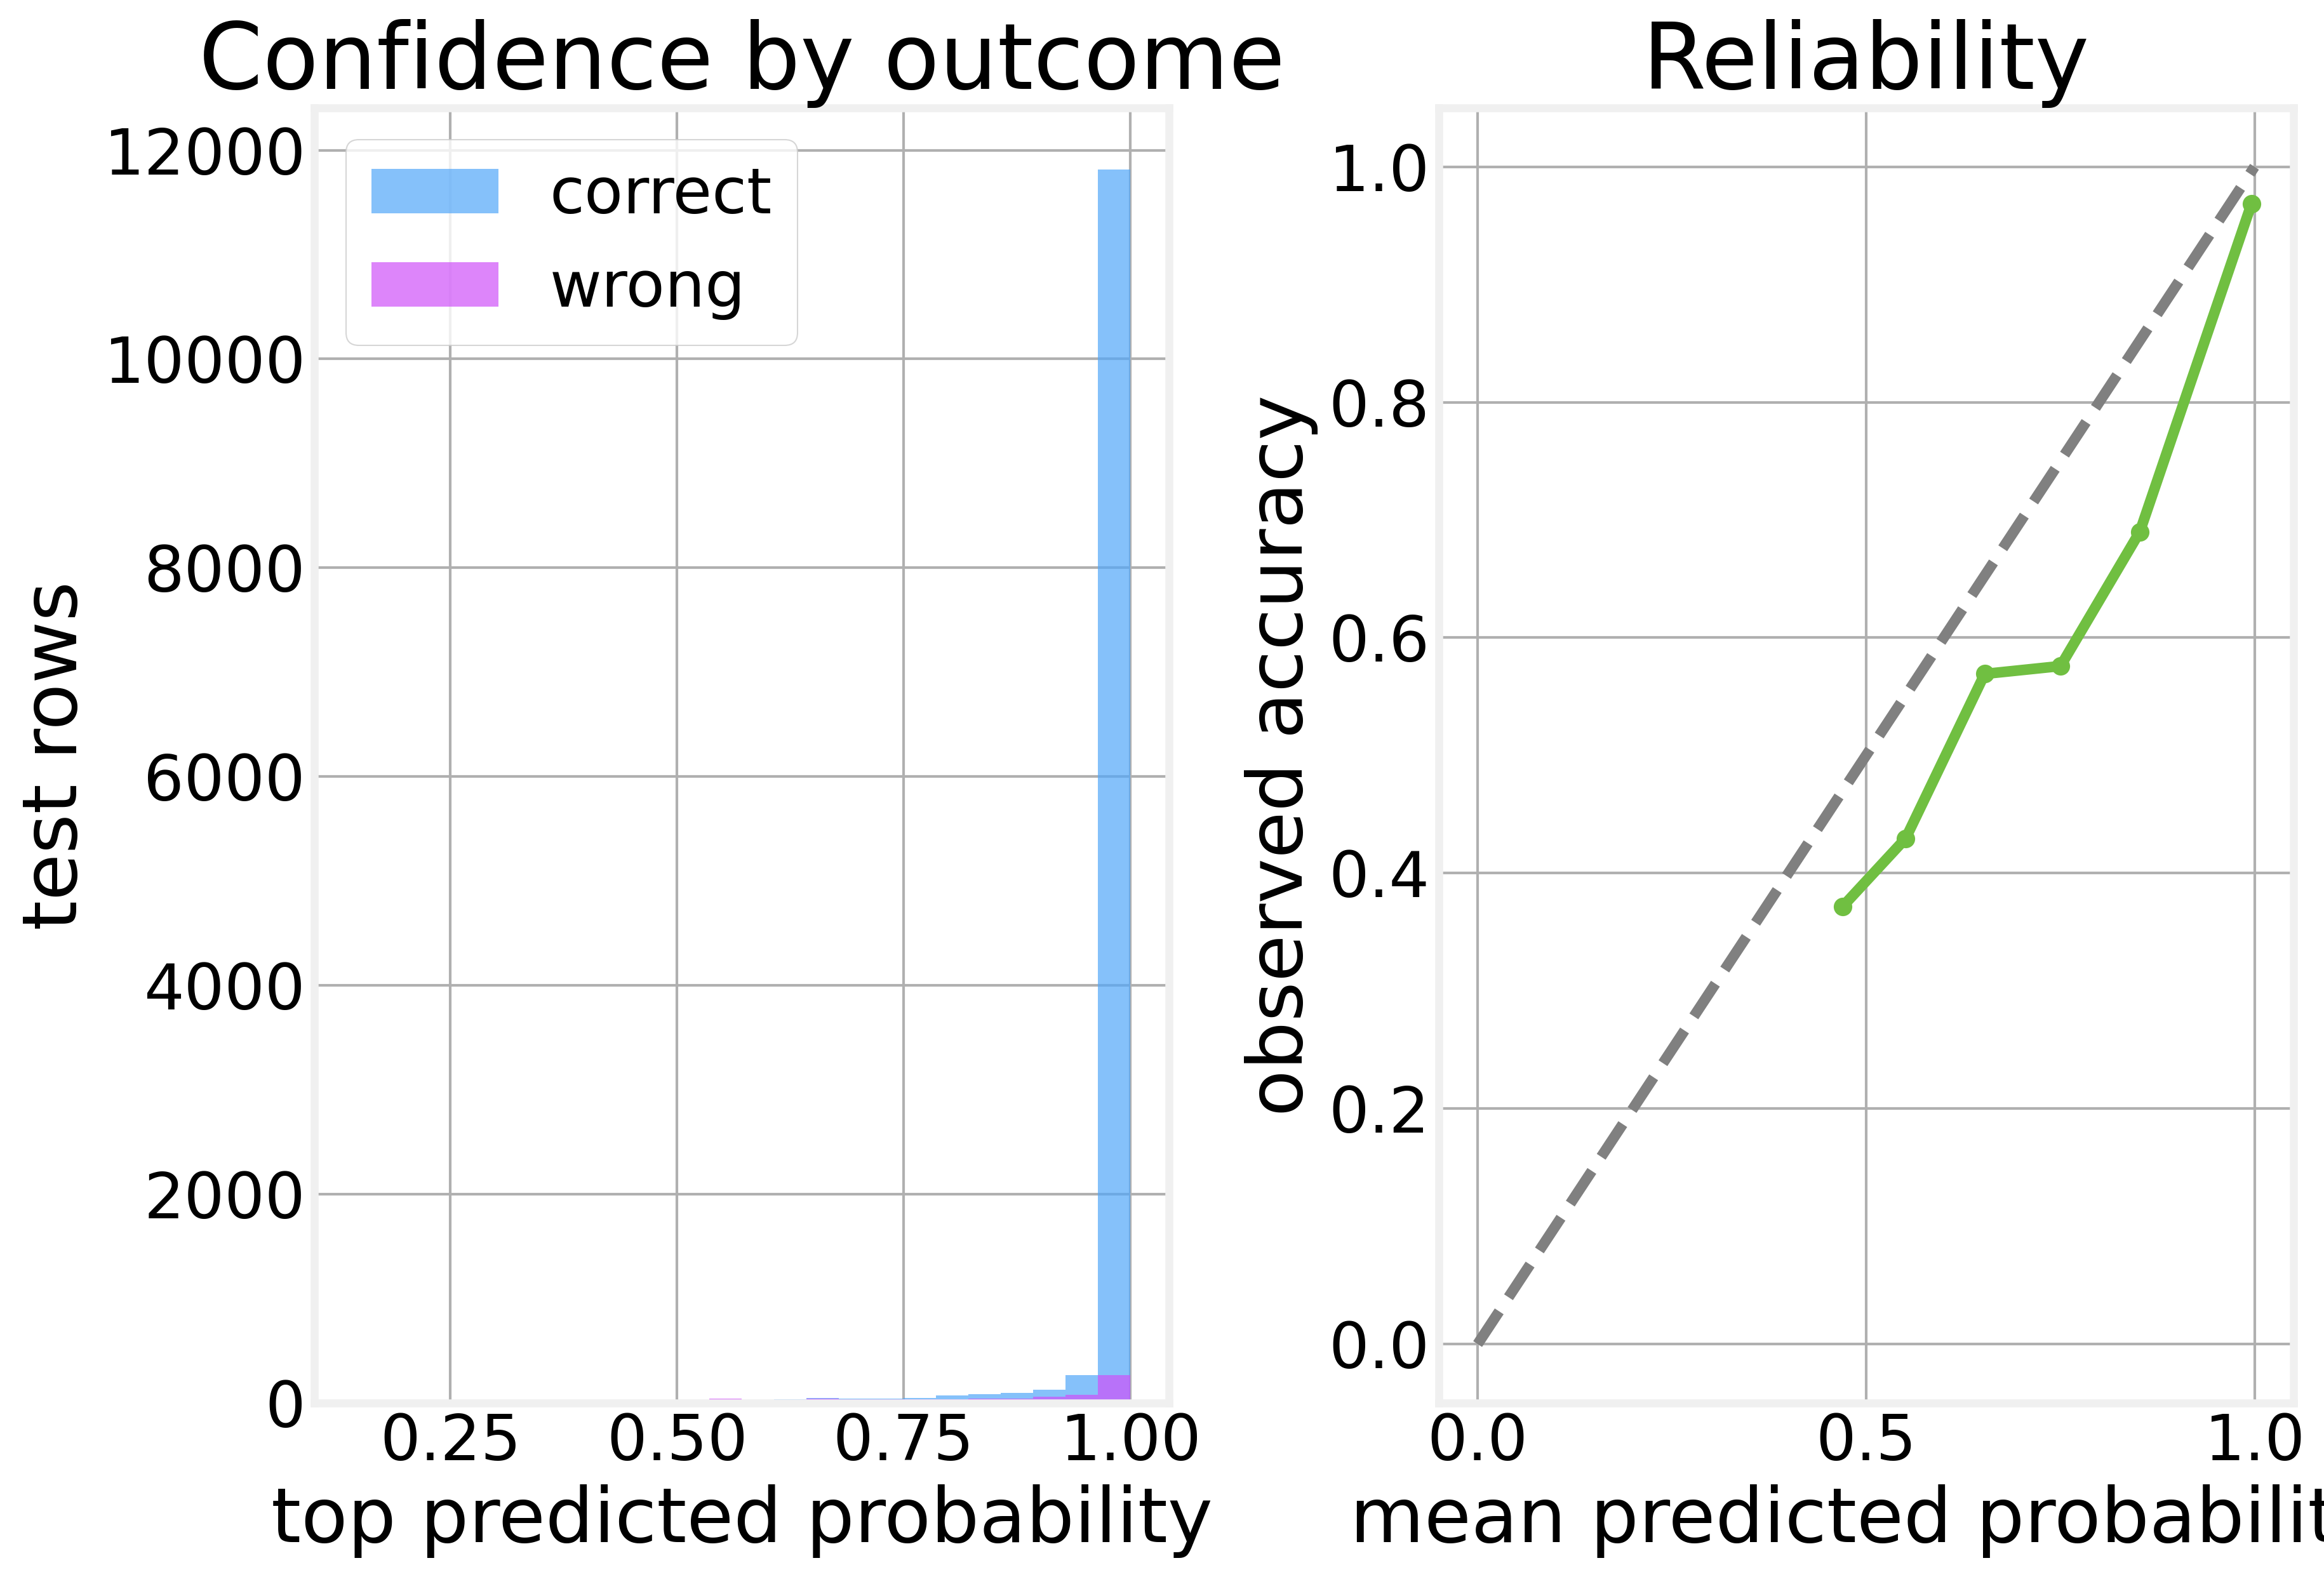

In [18]:
# Why confidence views: they separate "wrong and loud" from "wrong and unsure".
# P and classes_arr are the detector's softmax probabilities from the scoring cell.
maxp = P.max(axis=1)
correct = (pred == test.label.values)

fig, axes = plt.subplots(1, 2)
edges = np.linspace(1 / len(classes_arr), 1.0, 25)
axes[0].hist(maxp[correct], bins=edges, alpha=0.7, color=colors[0], label="correct")
axes[0].hist(maxp[~correct], bins=edges, alpha=0.7, color=colors[1], label="wrong")
axes[0].set_xlabel("top predicted probability")
axes[0].set_ylabel("test rows")
axes[0].set_title("Confidence by outcome")
axes[0].legend()

# Reliability: within each confidence bin, accuracy should track the diagonal.
bin_ids = np.clip(np.digitize(maxp, np.linspace(0, 1, 11)) - 1, 0, 9)
mids, obs = [], []
for b in range(10):
    m = bin_ids == b
    if m.sum() >= 20:
        mids.append(maxp[m].mean())
        obs.append(correct[m].mean())
axes[1].plot([0, 1], [0, 1], "--", color="gray")
axes[1].plot(mids, obs, "o-", color=colors[2])
axes[1].set_xlabel("mean predicted probability")
axes[1].set_ylabel("observed accuracy")
axes[1].set_title("Reliability")
plt.tight_layout()
plt.show()

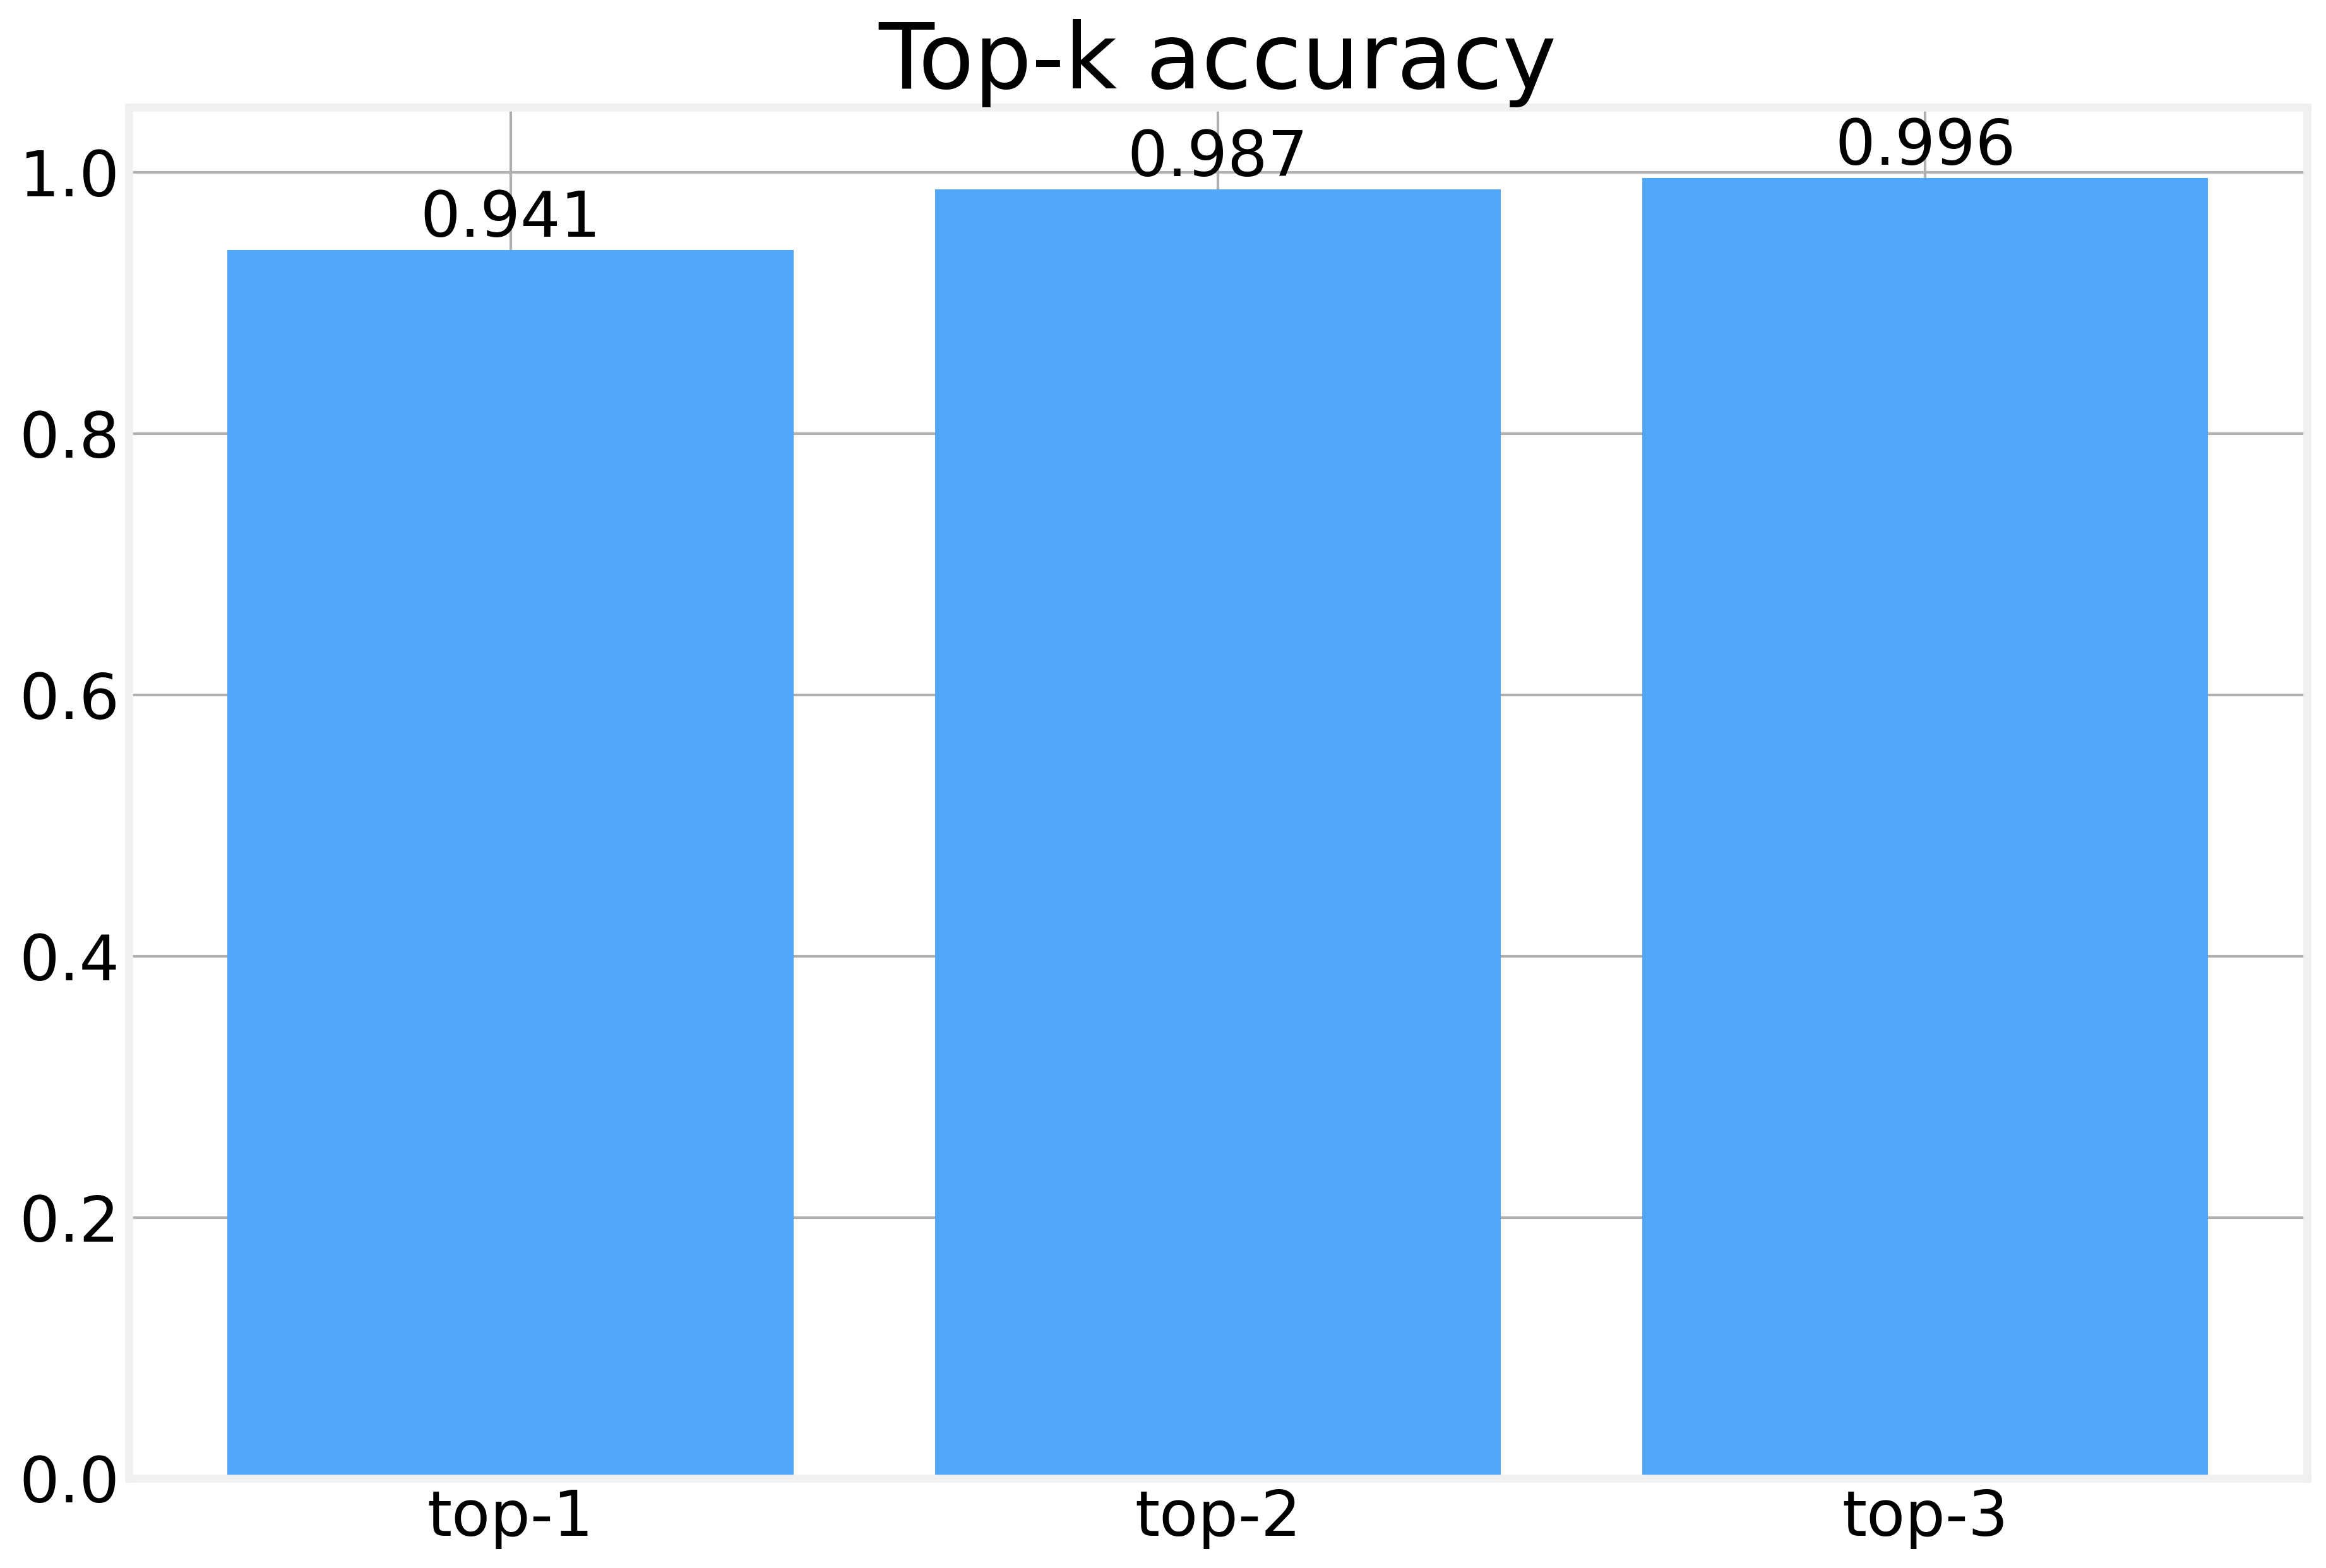

In [19]:
# Why top-k: with many classes, second place carries real information for triage.
true_idx = np.searchsorted(classes_arr, test.label.values)
order = np.argsort(-P, axis=1)
rank_true = np.argmax(order == true_idx[:, None], axis=1)
topk = {k: float((rank_true < k).mean()) for k in (1, 2, 3)}

fig, ax = plt.subplots()
ax.bar([f"top-{k}" for k in topk], list(topk.values()), color=colors[0])
ax.set_ylim(0, 1.05)
ax.set_title("Top-k accuracy")
for i, v in enumerate(topk.values()):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()

/tmp/ipykernel_2311937/3844930472.py:20: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


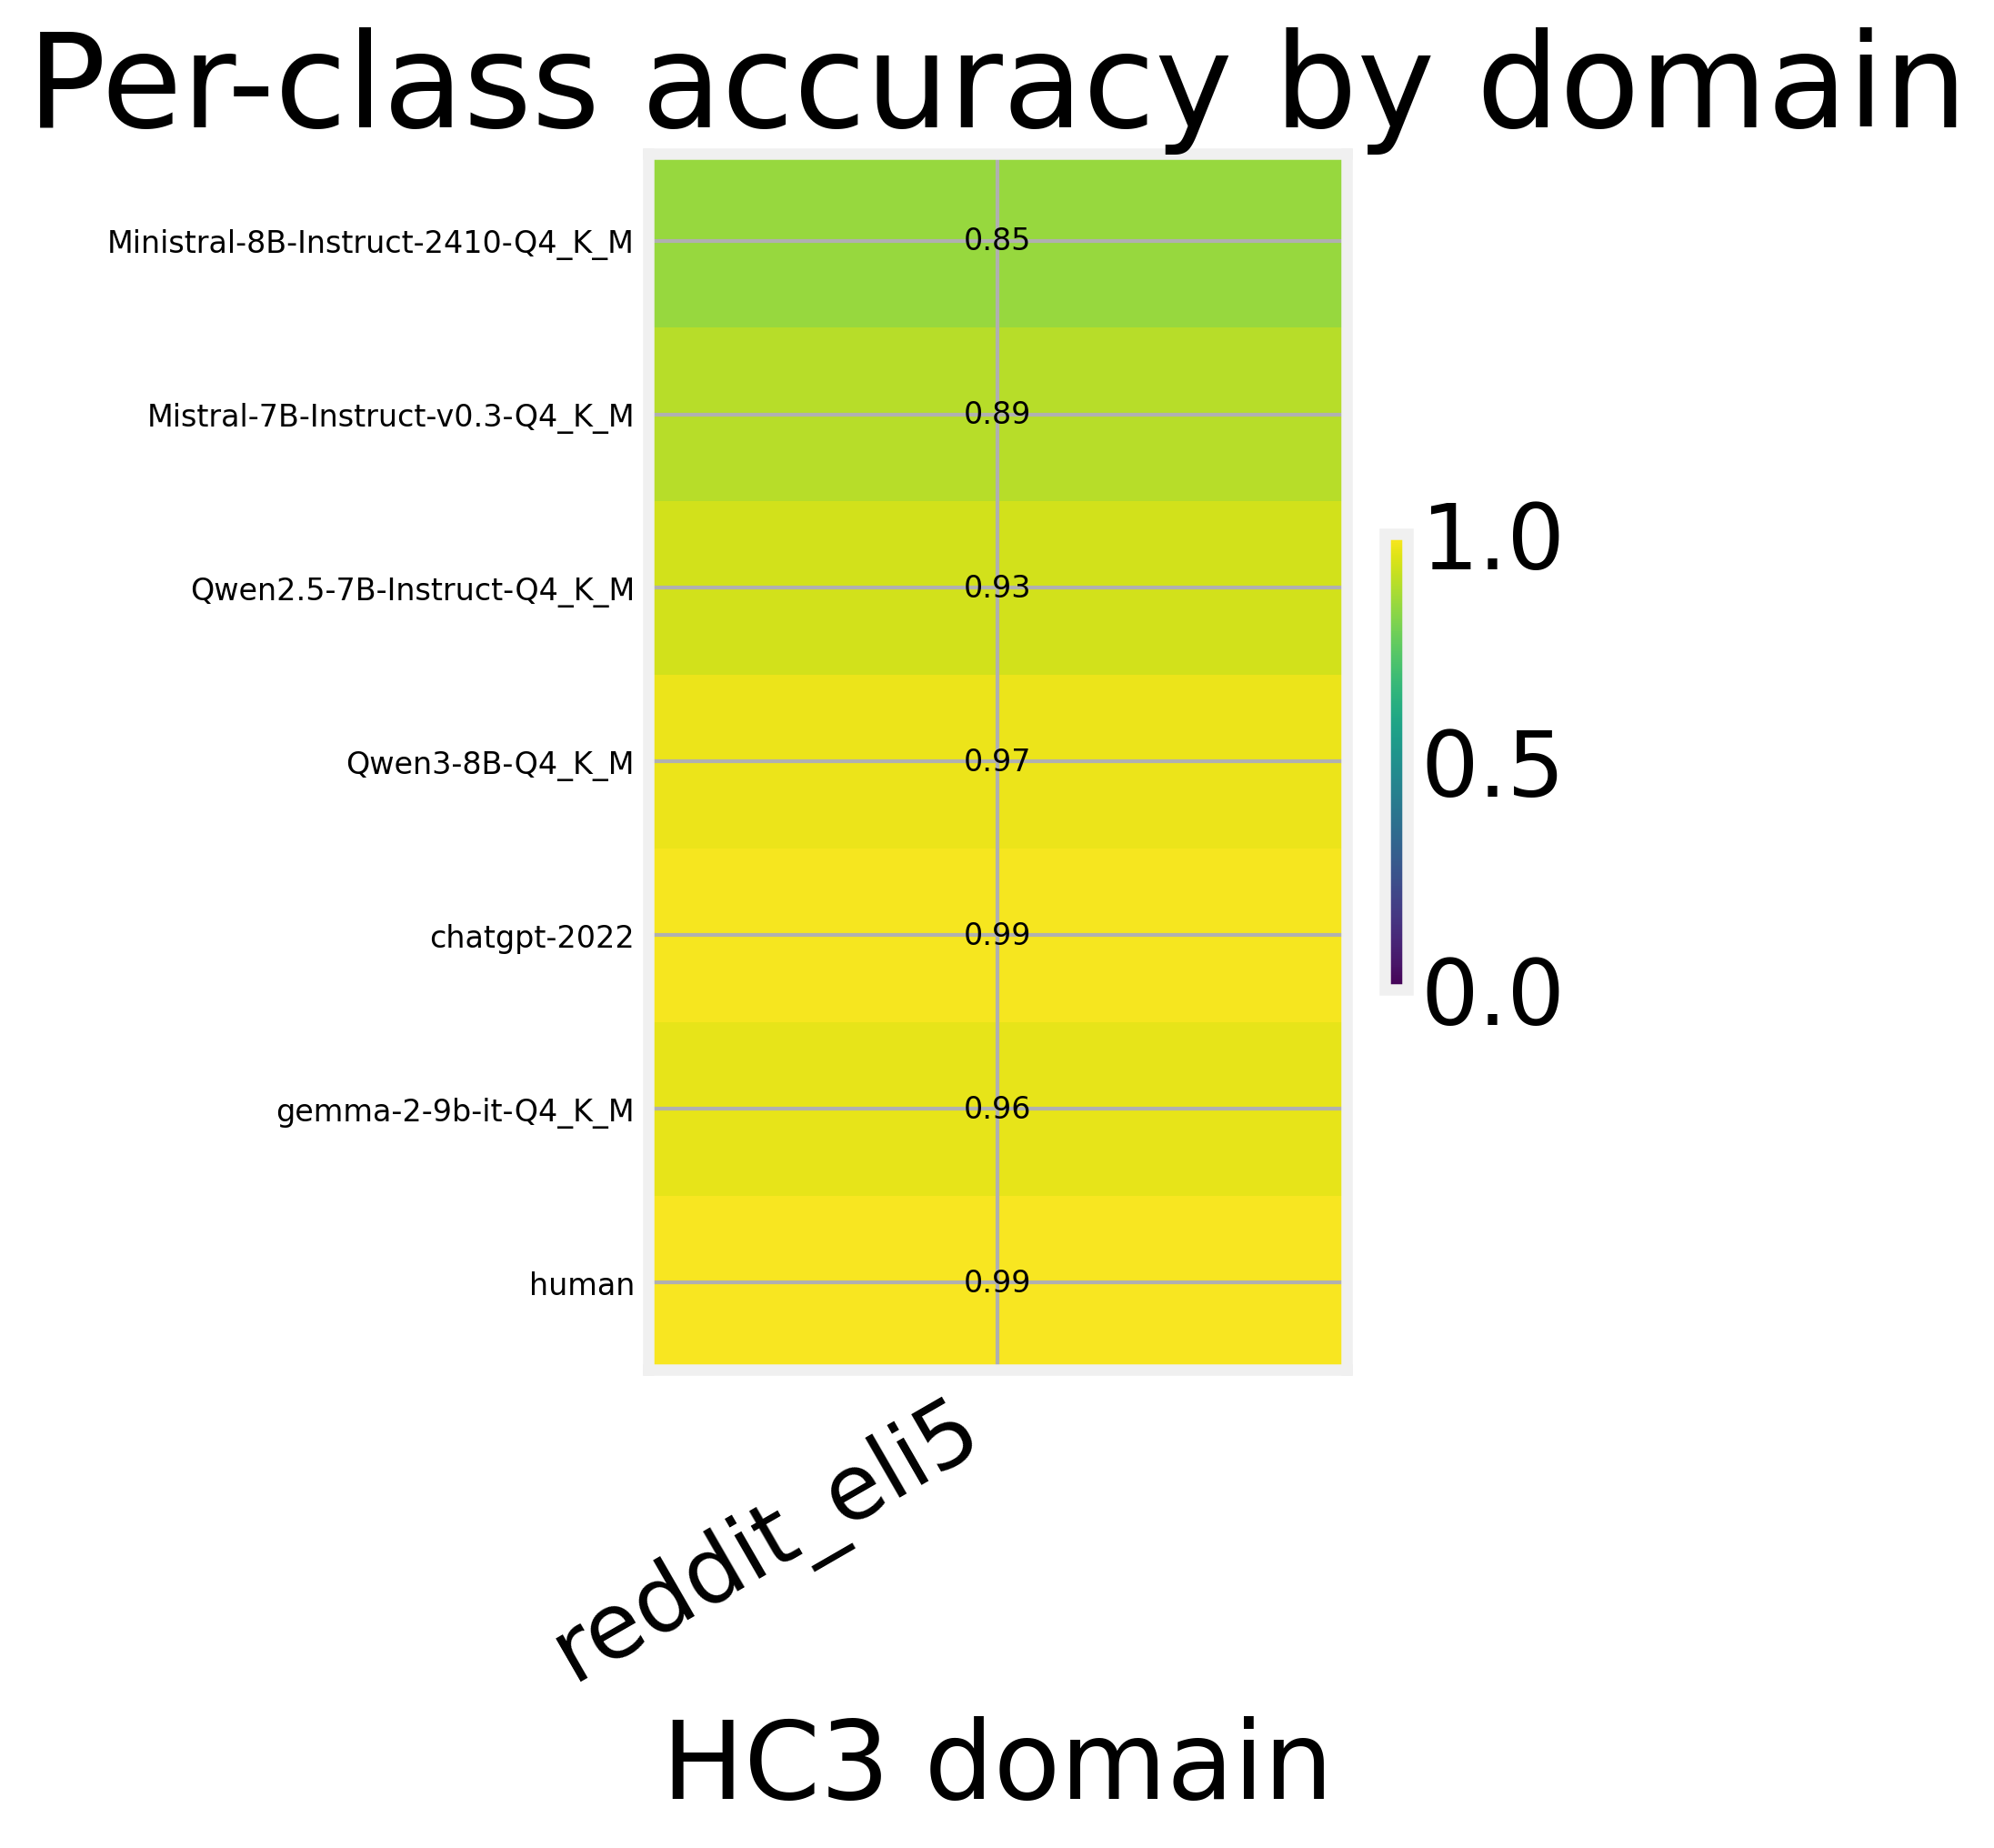

In [20]:
# Why this heatmap: it names the domain where each class hides. A class that only
# scores on one domain leans on topic register, not on the author's own habits.
heat = test_res.pivot_table(index="label", columns="domain",
                            values="correct", aggfunc="mean")
fig, ax = plt.subplots(figsize=(2 + 1.2 * heat.shape[1], 0.5 * heat.shape[0] + 2))
im = ax.imshow(heat.values, vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(heat.shape[1]))
ax.set_xticklabels(heat.columns, rotation=30, ha="right")
ax.set_yticks(range(heat.shape[0]))
ax.set_yticklabels(heat.index, fontsize=8)
ax.set_xlabel("HC3 domain")
ax.set_title("Per-class accuracy by domain")
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = heat.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    color="white" if v < 0.5 else "black", fontsize=8)
fig.colorbar(im, fraction=0.03)
plt.tight_layout()
plt.show()

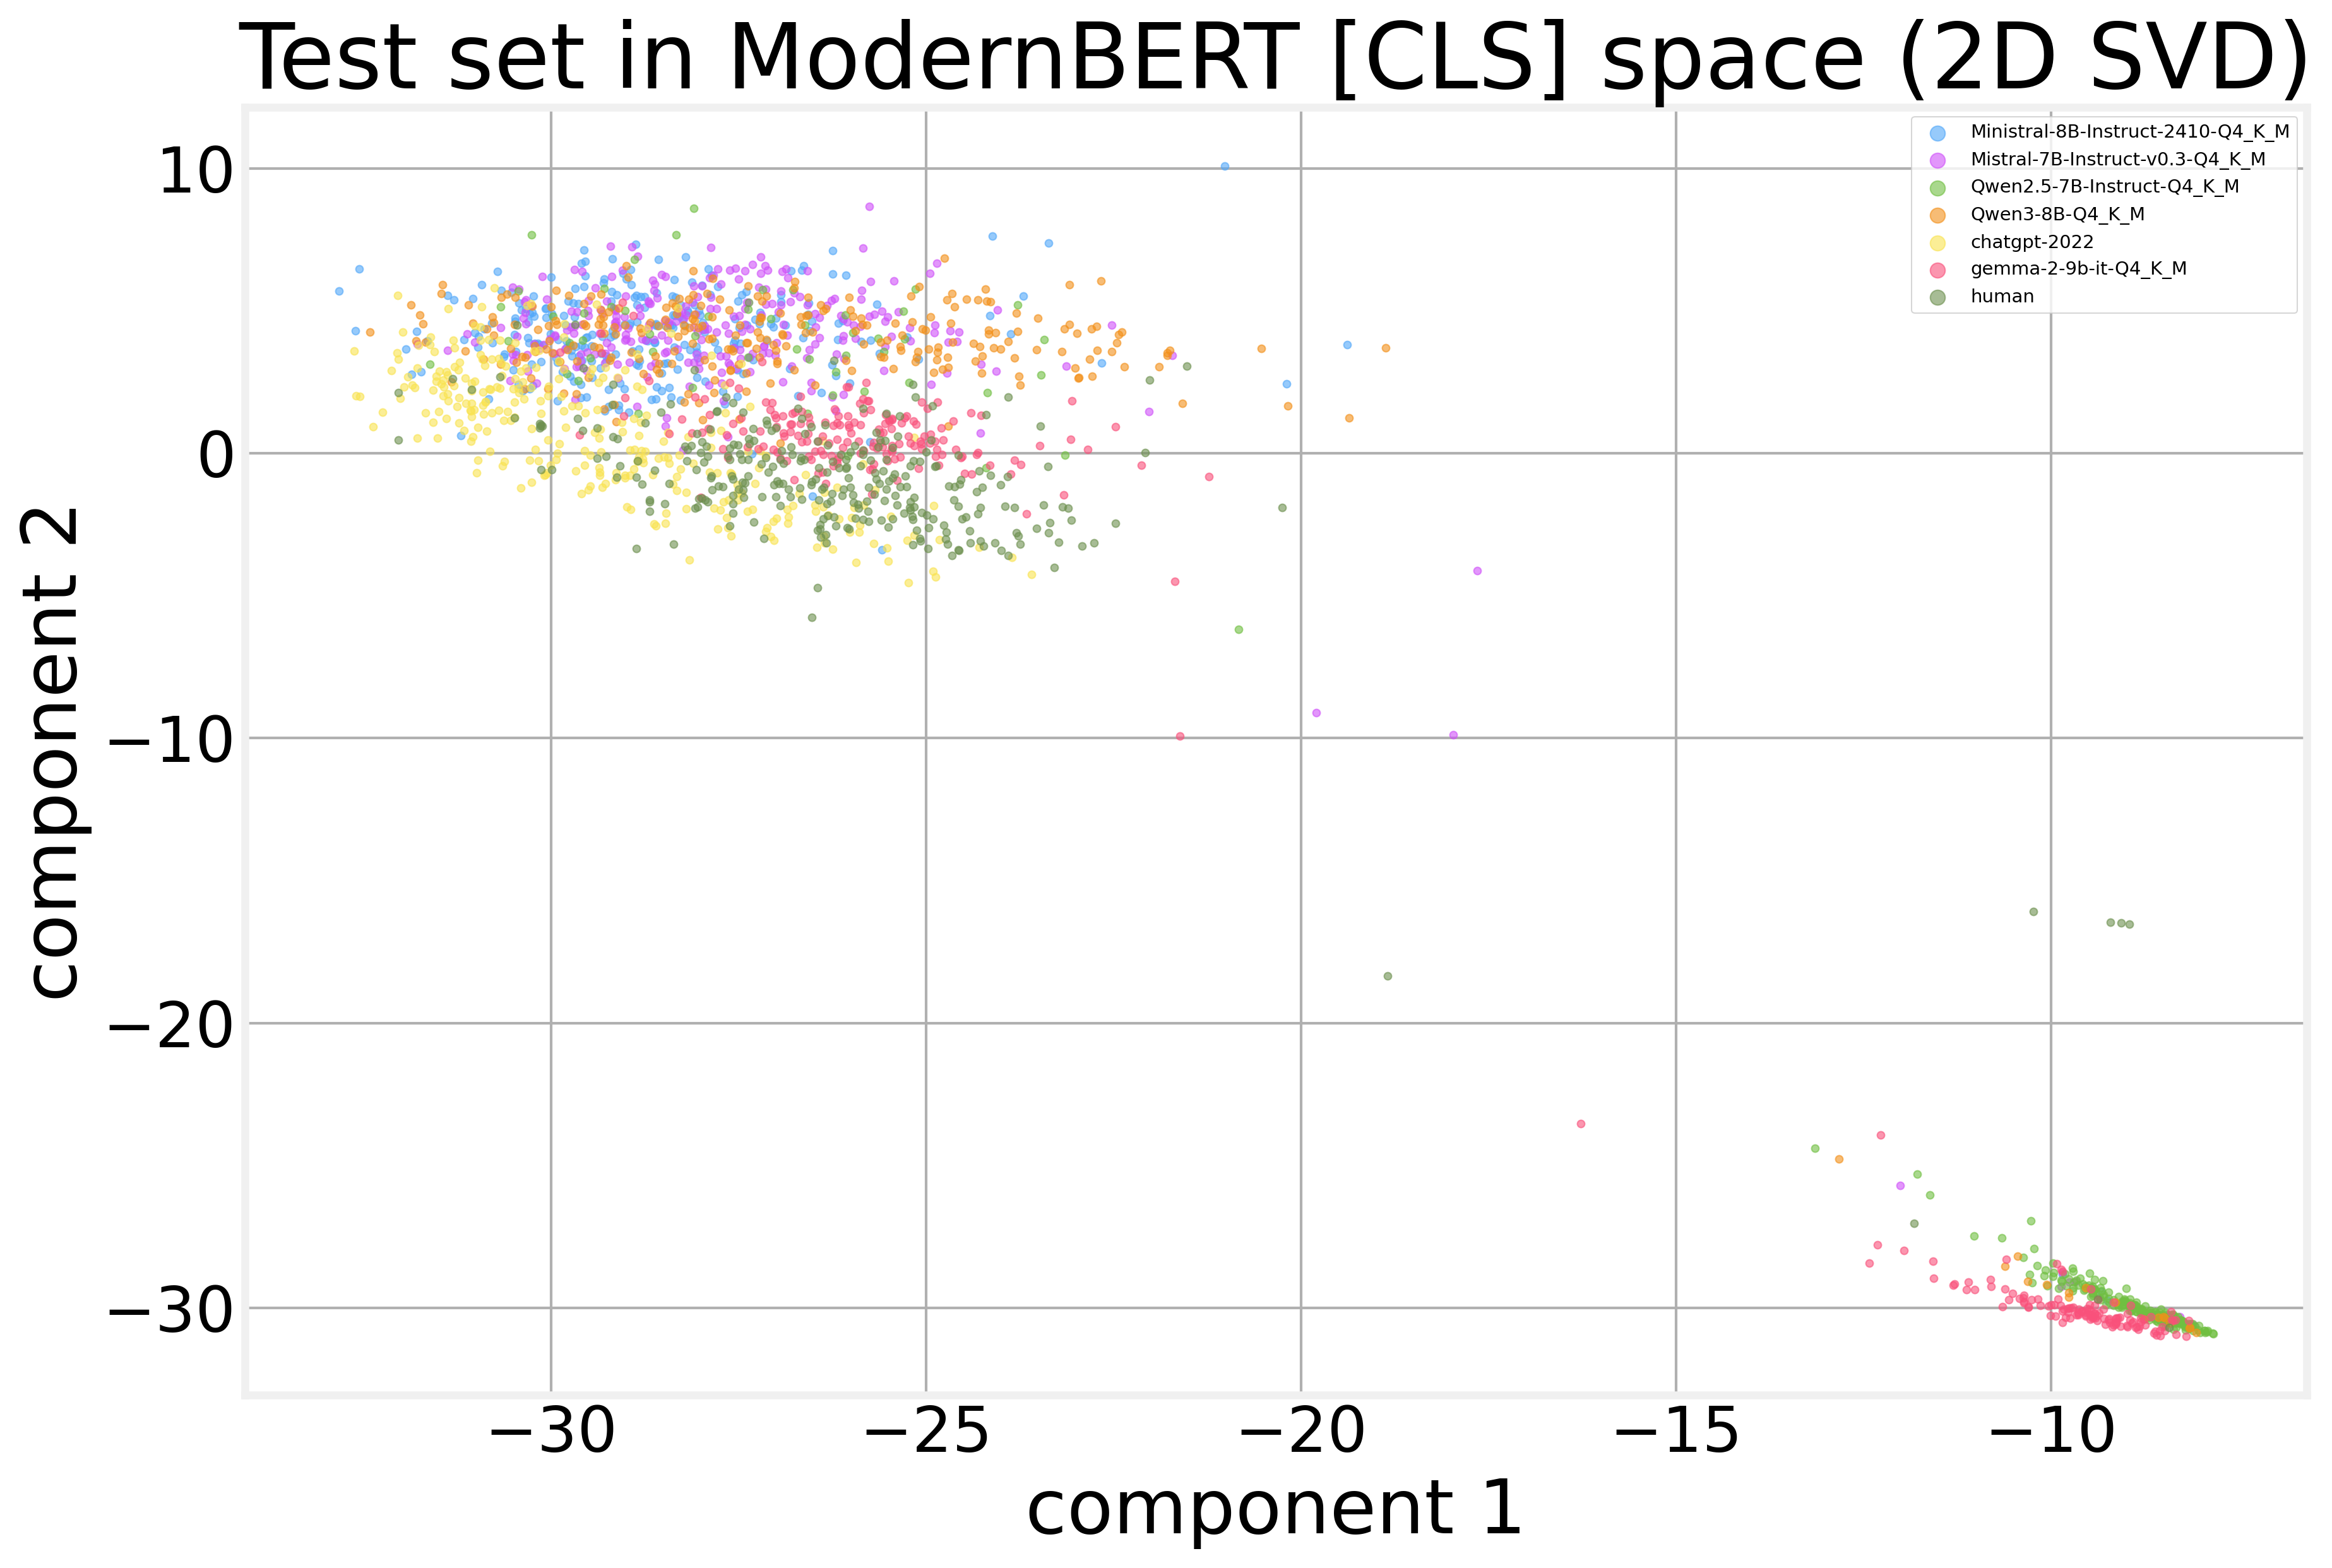

In [21]:
# Why [CLS] embeddings: this is the representation the classification head actually
# cuts. Families should form islands, siblings should touch, and the human cloud
# should sit far from every instruct model.
show = test if len(test) <= 2000 else test.sample(2000, random_state=SEED)
embs, texts_2d = [], show.text.tolist()
for i in range(0, len(texts_2d), 128):
    enc_b = tok_mb(texts_2d[i:i + 128], truncation=True, max_length=MAX_LEN,
                   padding=True, return_tensors="pt").to(dev)
    with torch.no_grad():
        h = model_mb(**enc_b, output_hidden_states=True).hidden_states[-1]
    embs.append(h[:, 0].float().cpu().numpy())
X2 = TruncatedSVD(n_components=2, random_state=SEED).fit_transform(np.vstack(embs))

fig, ax = plt.subplots()
for i, lab in enumerate(sorted(show.label.unique())):
    m = (show.label == lab).values
    ax.scatter(X2[m, 0], X2[m, 1], s=8, alpha=0.6,
               color=colors[i % len(colors)], label=lab)
ax.set_title("Test set in ModernBERT [CLS] space (2D SVD)")
ax.set_xlabel("component 1")
ax.set_ylabel("component 2")
ax.legend(fontsize=7, markerscale=2, loc="best")
plt.tight_layout()
plt.show()

## Reading the results

The gap panel comes first for a reason: a train score far above test means memorized prompts or too few classes worth of data, and nothing downstream matters until it closes. The per-class bars and the confusion matrix then name the hard classes — family siblings should own the off-diagonal, and on the last full run the Ministral ↔ Mistral pair was by far the hardest, exactly what shared pretraining and a shared instruction-tuning recipe predict. Human vs model at paragraph length should sit near the top of the F1 chart, but read that bar with the data section in mind: before the detokenization repair, the human class scored a near-perfect F1 on tokenizer spacing rather than style, so an honest number here is lower and means more.

The domain panel earns its place with one question: does the detector transfer register, or memorize it. Accuracy that holds across domains means style features; accuracy that collapses on one domain means topic features, and the per-class domain heatmap points at the class doing the collapsing. The length panel should climb through the 64-256 token bins and flatten — past `MAX_LEN` the detector is blind anyway, it reads only the first 256 tokens of each answer.

The confidence pair separates failure modes. Wrong-and-unsure errors cluster left and the reliability curve hugs the diagonal, so the probabilities work for triage; fine-tuned transformers tend to run overconfident, and a curve sagging below the diagonal at the right edge is the signature. Top-k tells you whether second place belongs in an interface — with sibling pairs in the pool, top-2 usually recovers most of what top-1 loses. The [CLS] map gives the geometry: families form islands, siblings overlap, and the human cloud and the ChatGPT-2022 cloud should sit far apart, three model generations separate them.

## Optional: the TF-IDF character n-gram baseline

Character 3-5 grams with logistic regression: no context, no semantics, just spelling, punctuation habits, and stock phrases, fit in minutes on CPU. Its job is to keep the transformer honest — whatever ModernBERT scores above this floor is what reading words in context actually buys, and the feature inspection below names the surface habits that carry the character-level signal. `TRAIN_BASELINE = False` skips this section and the comparison that follows.

In [22]:
if TRAIN_BASELINE:
    # Why sublinear TF: it stops one repeated phrase from owning a document.
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(analyzer="char", ngram_range=(3, 5),
                                  min_df=2, max_features=200_000, sublinear_tf=True)),
        ("clf", LogisticRegression(max_iter=2000)),
    ])
    t0 = time.time()
    pipe.fit(train.text, train.label)
    base_fit_s = time.time() - t0

    base_pred = pipe.predict(test.text)
    base_acc = accuracy_score(test.label, base_pred)
    base_macro = f1_score(test.label, base_pred, average="macro")
    joblib.dump(pipe, Path(RESULTS_DIR) / "detector_tfidf_logreg.joblib")
    print(f"fit {base_fit_s:.1f} s | test accuracy {base_acc:.3f} | "
          f"macro F1 {base_macro:.3f}\n")
    print(classification_report(test.label, base_pred, digits=3))
else:
    print("TRAIN_BASELINE is False, skipping the n-gram baseline")

fit 106.8 s | test accuracy 0.857 | macro F1 0.855

                                   precision    recall  f1-score   support

Ministral-8B-Instruct-2410-Q4_K_M      0.726     0.644     0.682      1936
  Mistral-7B-Instruct-v0.3-Q4_K_M      0.773     0.824     0.798      1936
       Qwen2.5-7B-Instruct-Q4_K_M      0.861     0.868     0.864      1936
                  Qwen3-8B-Q4_K_M      0.896     0.903     0.900      1936
                     chatgpt-2022      0.954     0.951     0.952      1922
             gemma-2-9b-it-Q4_K_M      0.837     0.834     0.835      1936
                            human      0.939     0.973     0.956      1956

                         accuracy                          0.857     13558
                        macro avg      0.855     0.857     0.855     13558
                     weighted avg      0.855     0.857     0.855     13558



In [23]:
# Why inspect features: the top n-grams name the habits a character model keys on —
# and after the detokenization repair, the human row should read as style (' . ' and
# ' , ' would mean the tokenization fingerprint is back).
if TRAIN_BASELINE:
    vec = pipe.named_steps["tfidf"]
    clf = pipe.named_steps["clf"]
    feats = vec.get_feature_names_out()
    coefs = clf.coef_ if len(clf.classes_) > 2 else np.vstack([-clf.coef_[0],
                                                               clf.coef_[0]])
    for i, lab in enumerate(clf.classes_):
        top = [repr(feats[k]) for k in np.argsort(coefs[i])[-8:][::-1]]
        print(f"{lab}\n  {', '.join(top)}\n")

Ministral-8B-Instruct-2410-Q4_K_M
  'sure,', ' ima', ' imag', 'sure', ', ima', ', im', 'e, im', 're, i'

Mistral-7B-Instruct-v0.3-Q4_K_M
  ' imag', ' ima', 'e if', 'e if ', ' du', 'due ', 'due', 'due t'

Qwen2.5-7B-Instruct-Q4_K_M
  'agine', 'imagi', 'magin', 'magi', 'gine ', 'imag', 'agin', 'gine'

Qwen3-8B-Q4_K_M
  '’s ', 't’s ', 't’s', 'n’t', '’t ', 'n’t ', ' — ', '—it'

chatgpt-2022
  'it is', 't is ', ' it i', 't is', 'it i', 'n\\n', '\\n\\', '\\n\\n'

gemma-2-9b-it-Q4_K_M
  '! t', '! th', 's! ', '! it', '! i', ' – ', '! the', 't! '

human
  ' - ', ' i ', ' * ', ' / ', " ' ", '...', ' etc', ' will'



## ModernBERT vs the baseline, instance by instance

This whole section runs only with `TRAIN_BASELINE = True`. Aggregate scores answer "which is better"; the instance level answers "at what". Both detectors scored the same held-out prompts, so every disagreement is attributable: the rows only ModernBERT gets right measure what reading words in context buys over character n-grams, and the rows only the baseline gets right measure what truncation at `MAX_LEN` tokens costs. The comparison table saves one row per test instance with both detectors' prediction, confidence, and the rank each gave the true class.

In [24]:
if TRAIN_BASELINE:
    # ModernBERT's probabilities (P, classes_arr) come from the scoring section;
    # only the baseline's are computed here.
    P_base = pipe.predict_proba(test.text)
    base_classes = np.array(pipe.classes_)
    C_BASE, C_TRF = colors[0], colors[3]

    def per_instance(Pm, classes, prefix):
        true_idx = np.searchsorted(classes, test.label.values)
        order = np.argsort(-Pm, axis=1)
        return pd.DataFrame({
            f"{prefix}_pred": classes[Pm.argmax(1)],
            f"{prefix}_maxp": Pm.max(1),
            f"{prefix}_p_true": Pm[np.arange(len(Pm)), true_idx],
            f"{prefix}_rank_true": np.argmax(order == true_idx[:, None], axis=1) + 1,
        }, index=test.index)

    comp = pd.concat([test[["prompt_idx", "label", "domain", "out_tokens", "text"]],
                      per_instance(P_base, base_classes, "base"),
                      per_instance(P, classes_arr, "trf")], axis=1)
    comp["base_correct"] = comp.base_pred == comp.label
    comp["trf_correct"] = comp.trf_pred == comp.label
    comp.to_json(Path(RESULTS_DIR) / "detector_comparison_test.jsonl",
                 orient="records", lines=True)
    print(f"{len(comp):,} test rows scored by both detectors")
else:
    print("TRAIN_BASELINE is False, no baseline to compare against")

13,558 test rows scored by both detectors


TF-IDF     accuracy 0.8568 | macro F1 0.8554
ModernBERT accuracy 0.9407 | macro F1 0.9408
McNemar exact: 1,437 vs 300 discordant rows, p = 1.12e-177


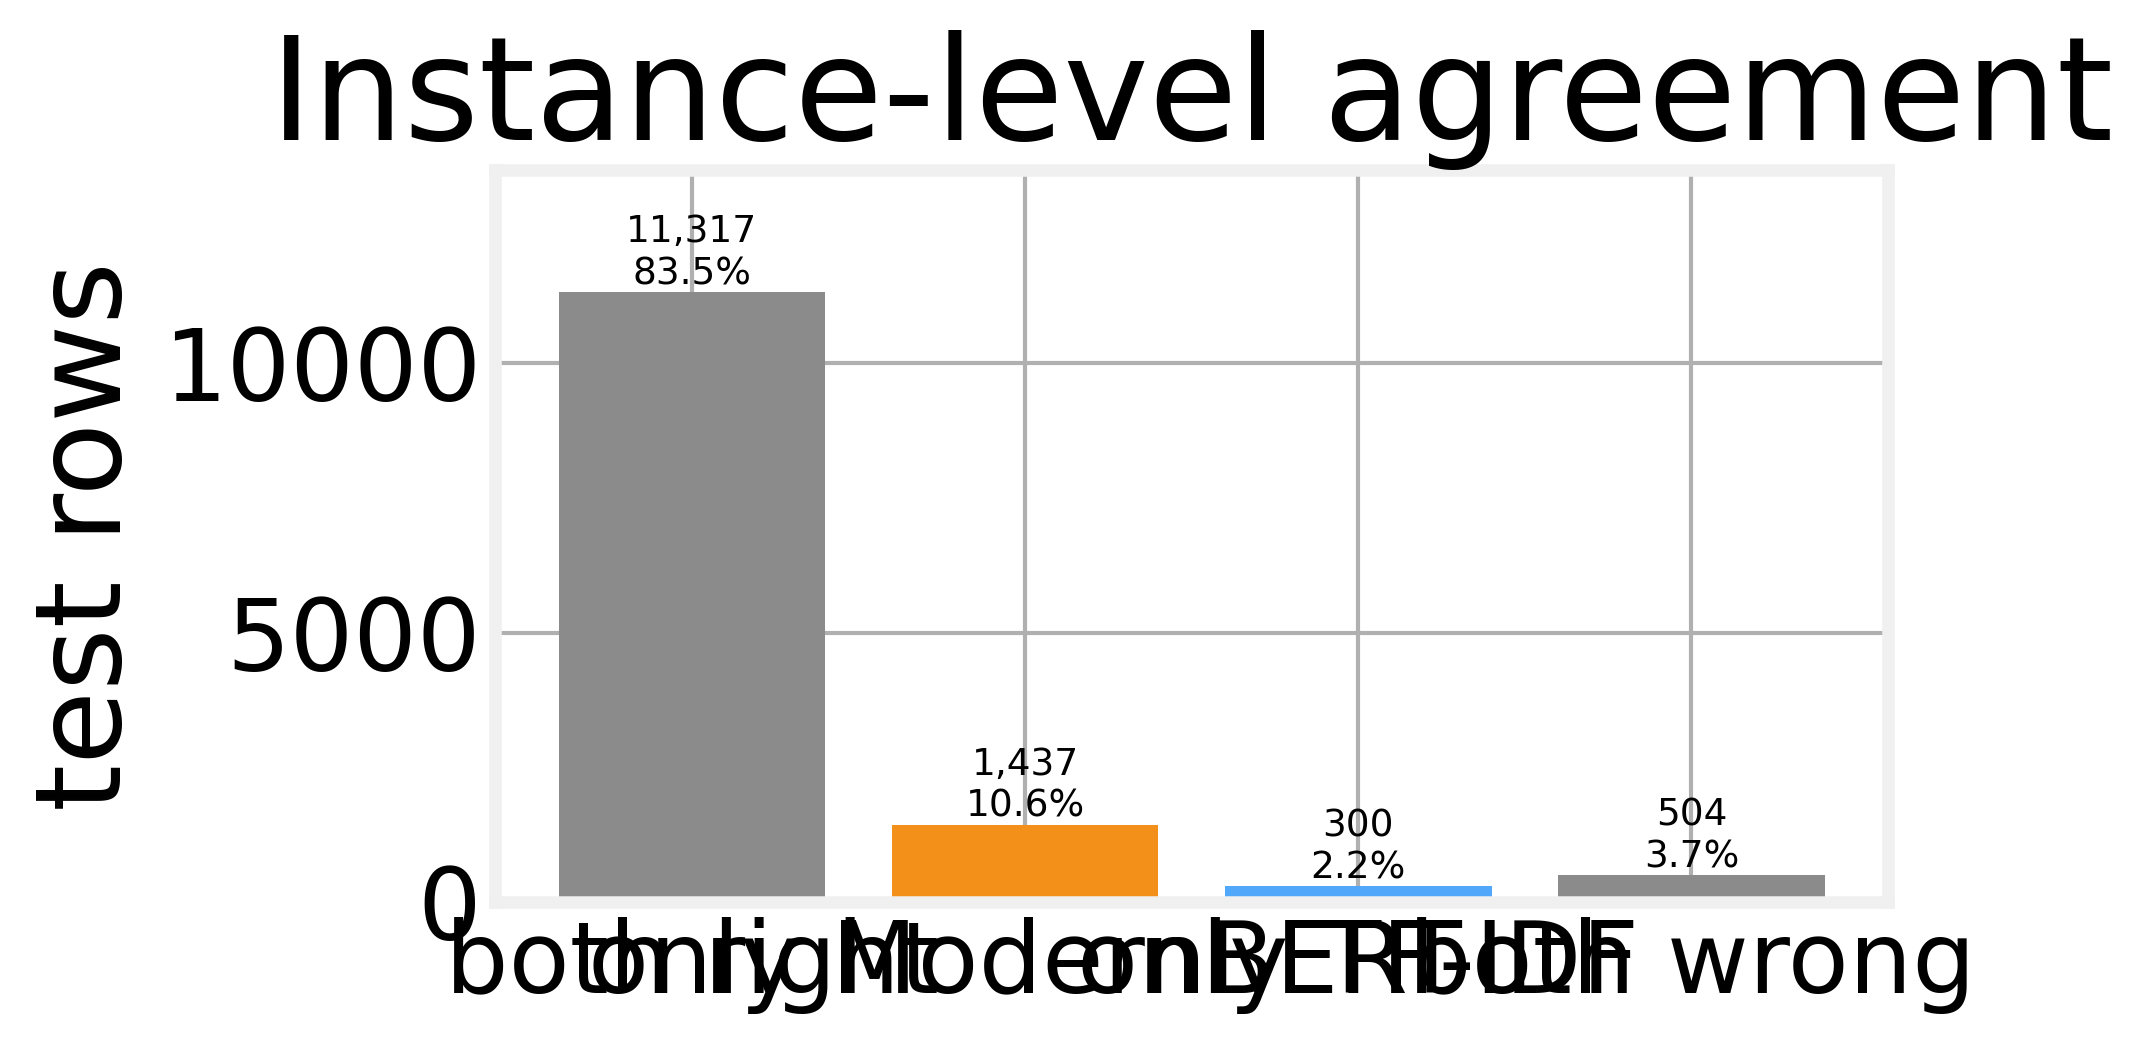

In [25]:
from scipy.stats import binomtest

# Why the two middle bars matter most: rows only one detector gets right are the entire
# case for (or against) the transformer. McNemar's exact test on the discordant pair
# says whether the imbalance is real or a coin flip.
if TRAIN_BASELINE:
    both = int((comp.base_correct & comp.trf_correct).sum())
    only_t = int((~comp.base_correct & comp.trf_correct).sum())
    only_b = int((comp.base_correct & ~comp.trf_correct).sum())
    neither = int((~comp.base_correct & ~comp.trf_correct).sum())

    acc_b, acc_t = comp.base_correct.mean(), comp.trf_correct.mean()
    mf1_b = f1_score(comp.label, comp.base_pred, average="macro")
    mf1_t = f1_score(comp.label, comp.trf_pred, average="macro")
    print(f"TF-IDF     accuracy {acc_b:.4f} | macro F1 {mf1_b:.4f}")
    print(f"ModernBERT accuracy {acc_t:.4f} | macro F1 {mf1_t:.4f}")
    p_mcnemar = binomtest(only_t, only_t + only_b, 0.5).pvalue
    print(f"McNemar exact: {only_t:,} vs {only_b:,} discordant rows, p = {p_mcnemar:.2e}")

    cats = [("both right", both, colors[7]), ("only ModernBERT", only_t, C_TRF),
            ("only TF-IDF", only_b, C_BASE), ("both wrong", neither, colors[7])]
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar([c for c, _, _ in cats], [n for _, n, _ in cats],
           color=[c for _, _, c in cats])
    for i, (_, n, _) in enumerate(cats):
        ax.text(i, n, f"{n:,}\n{n / len(comp):.1%}", ha="center", va="bottom",
                fontsize=9)
    ax.set_ylim(0, both * 1.2)
    ax.set_ylabel("test rows")
    ax.set_title("Instance-level agreement")
    plt.tight_layout()
    plt.show()

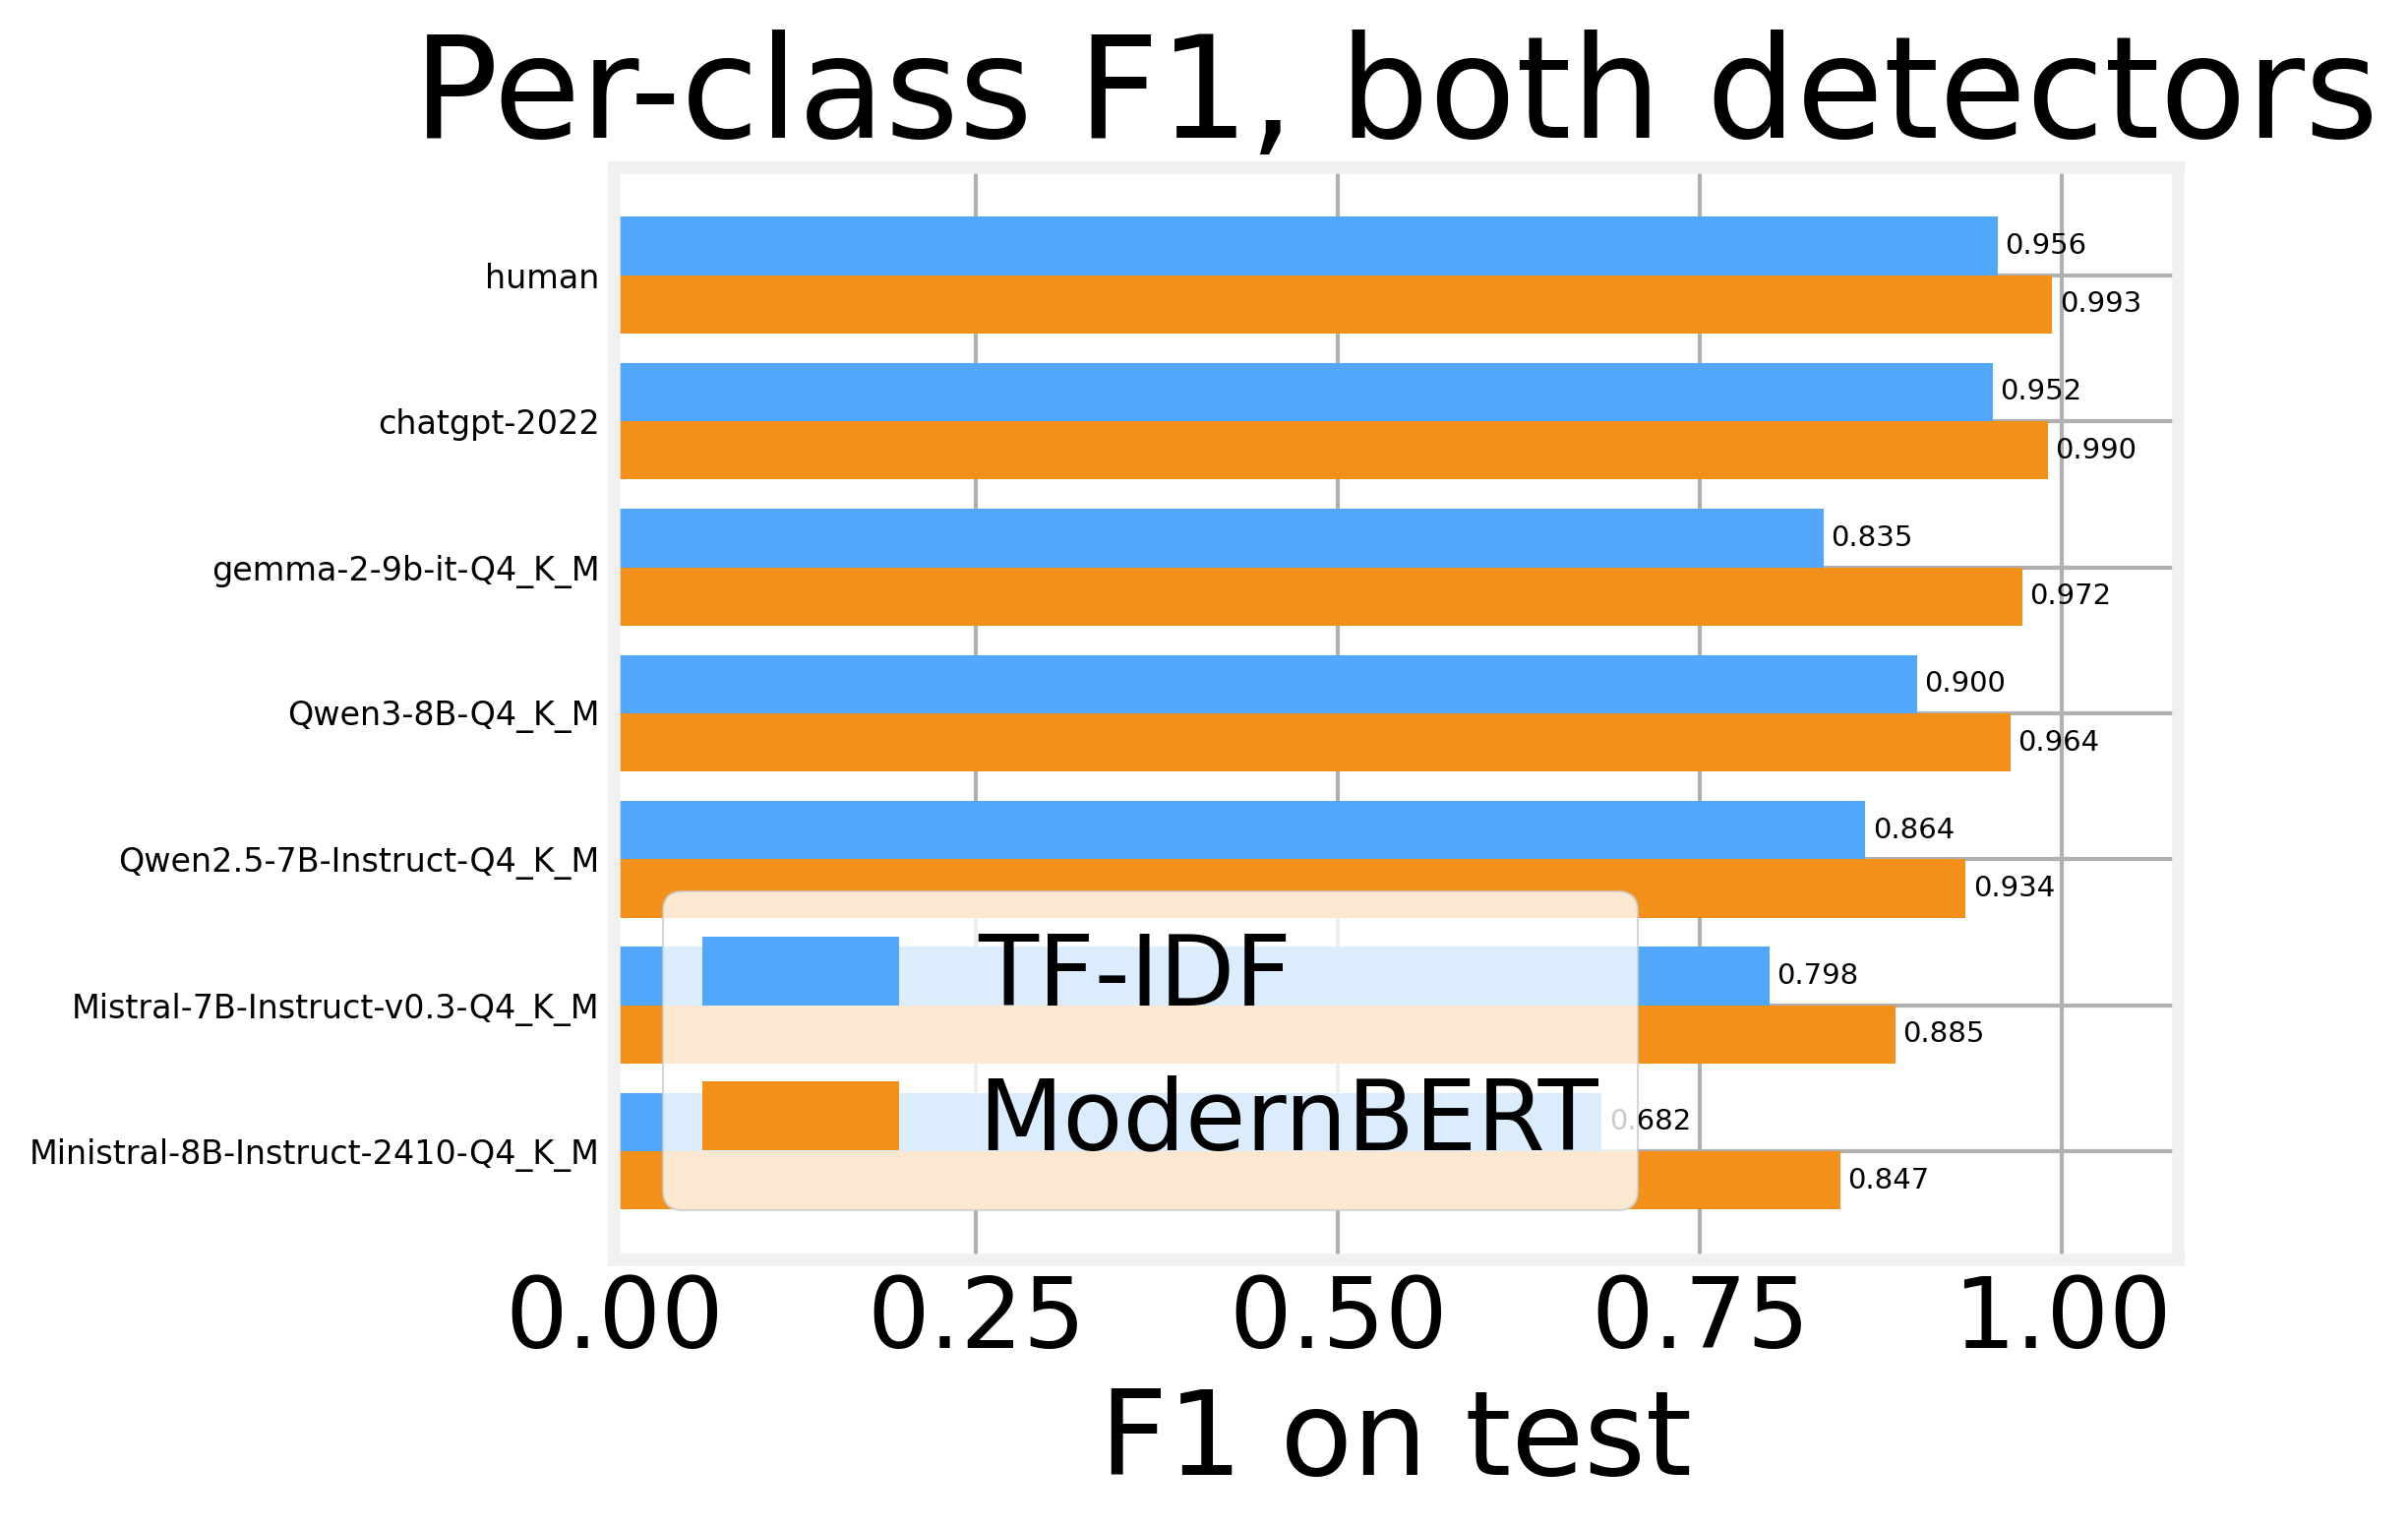

In [26]:
# Why paired bars: a class where only one detector moves names the kind of signal it found.
if TRAIN_BASELINE:
    labels_sorted = sorted(comp.label.unique())
    f1b = f1_score(comp.label, comp.base_pred, average=None, labels=labels_sorted)
    f1t = f1_score(comp.label, comp.trf_pred, average=None, labels=labels_sorted)
    order = np.argsort(f1t)

    y = np.arange(len(labels_sorted))
    fig, ax = plt.subplots(figsize=(8, 0.6 * len(labels_sorted) + 1.5))
    ax.barh(y + 0.2, f1b[order], height=0.4, color=C_BASE, label="TF-IDF")
    ax.barh(y - 0.2, f1t[order], height=0.4, color=C_TRF, label="ModernBERT")
    ax.set_yticks(y)
    ax.set_yticklabels([labels_sorted[i] for i in order], fontsize=8)
    ax.set_xlim(0, 1.08)
    ax.set_xlabel("F1 on test")
    ax.set_title("Per-class F1, both detectors")
    for yi, i in zip(y, order):
        ax.text(f1b[i] + 0.005, yi + 0.2, f"{f1b[i]:.3f}", va="center", fontsize=7)
        ax.text(f1t[i] + 0.005, yi - 0.2, f"{f1t[i]:.3f}", va="center", fontsize=7)
    ax.legend(loc="lower left")
    plt.tight_layout()
    plt.show()

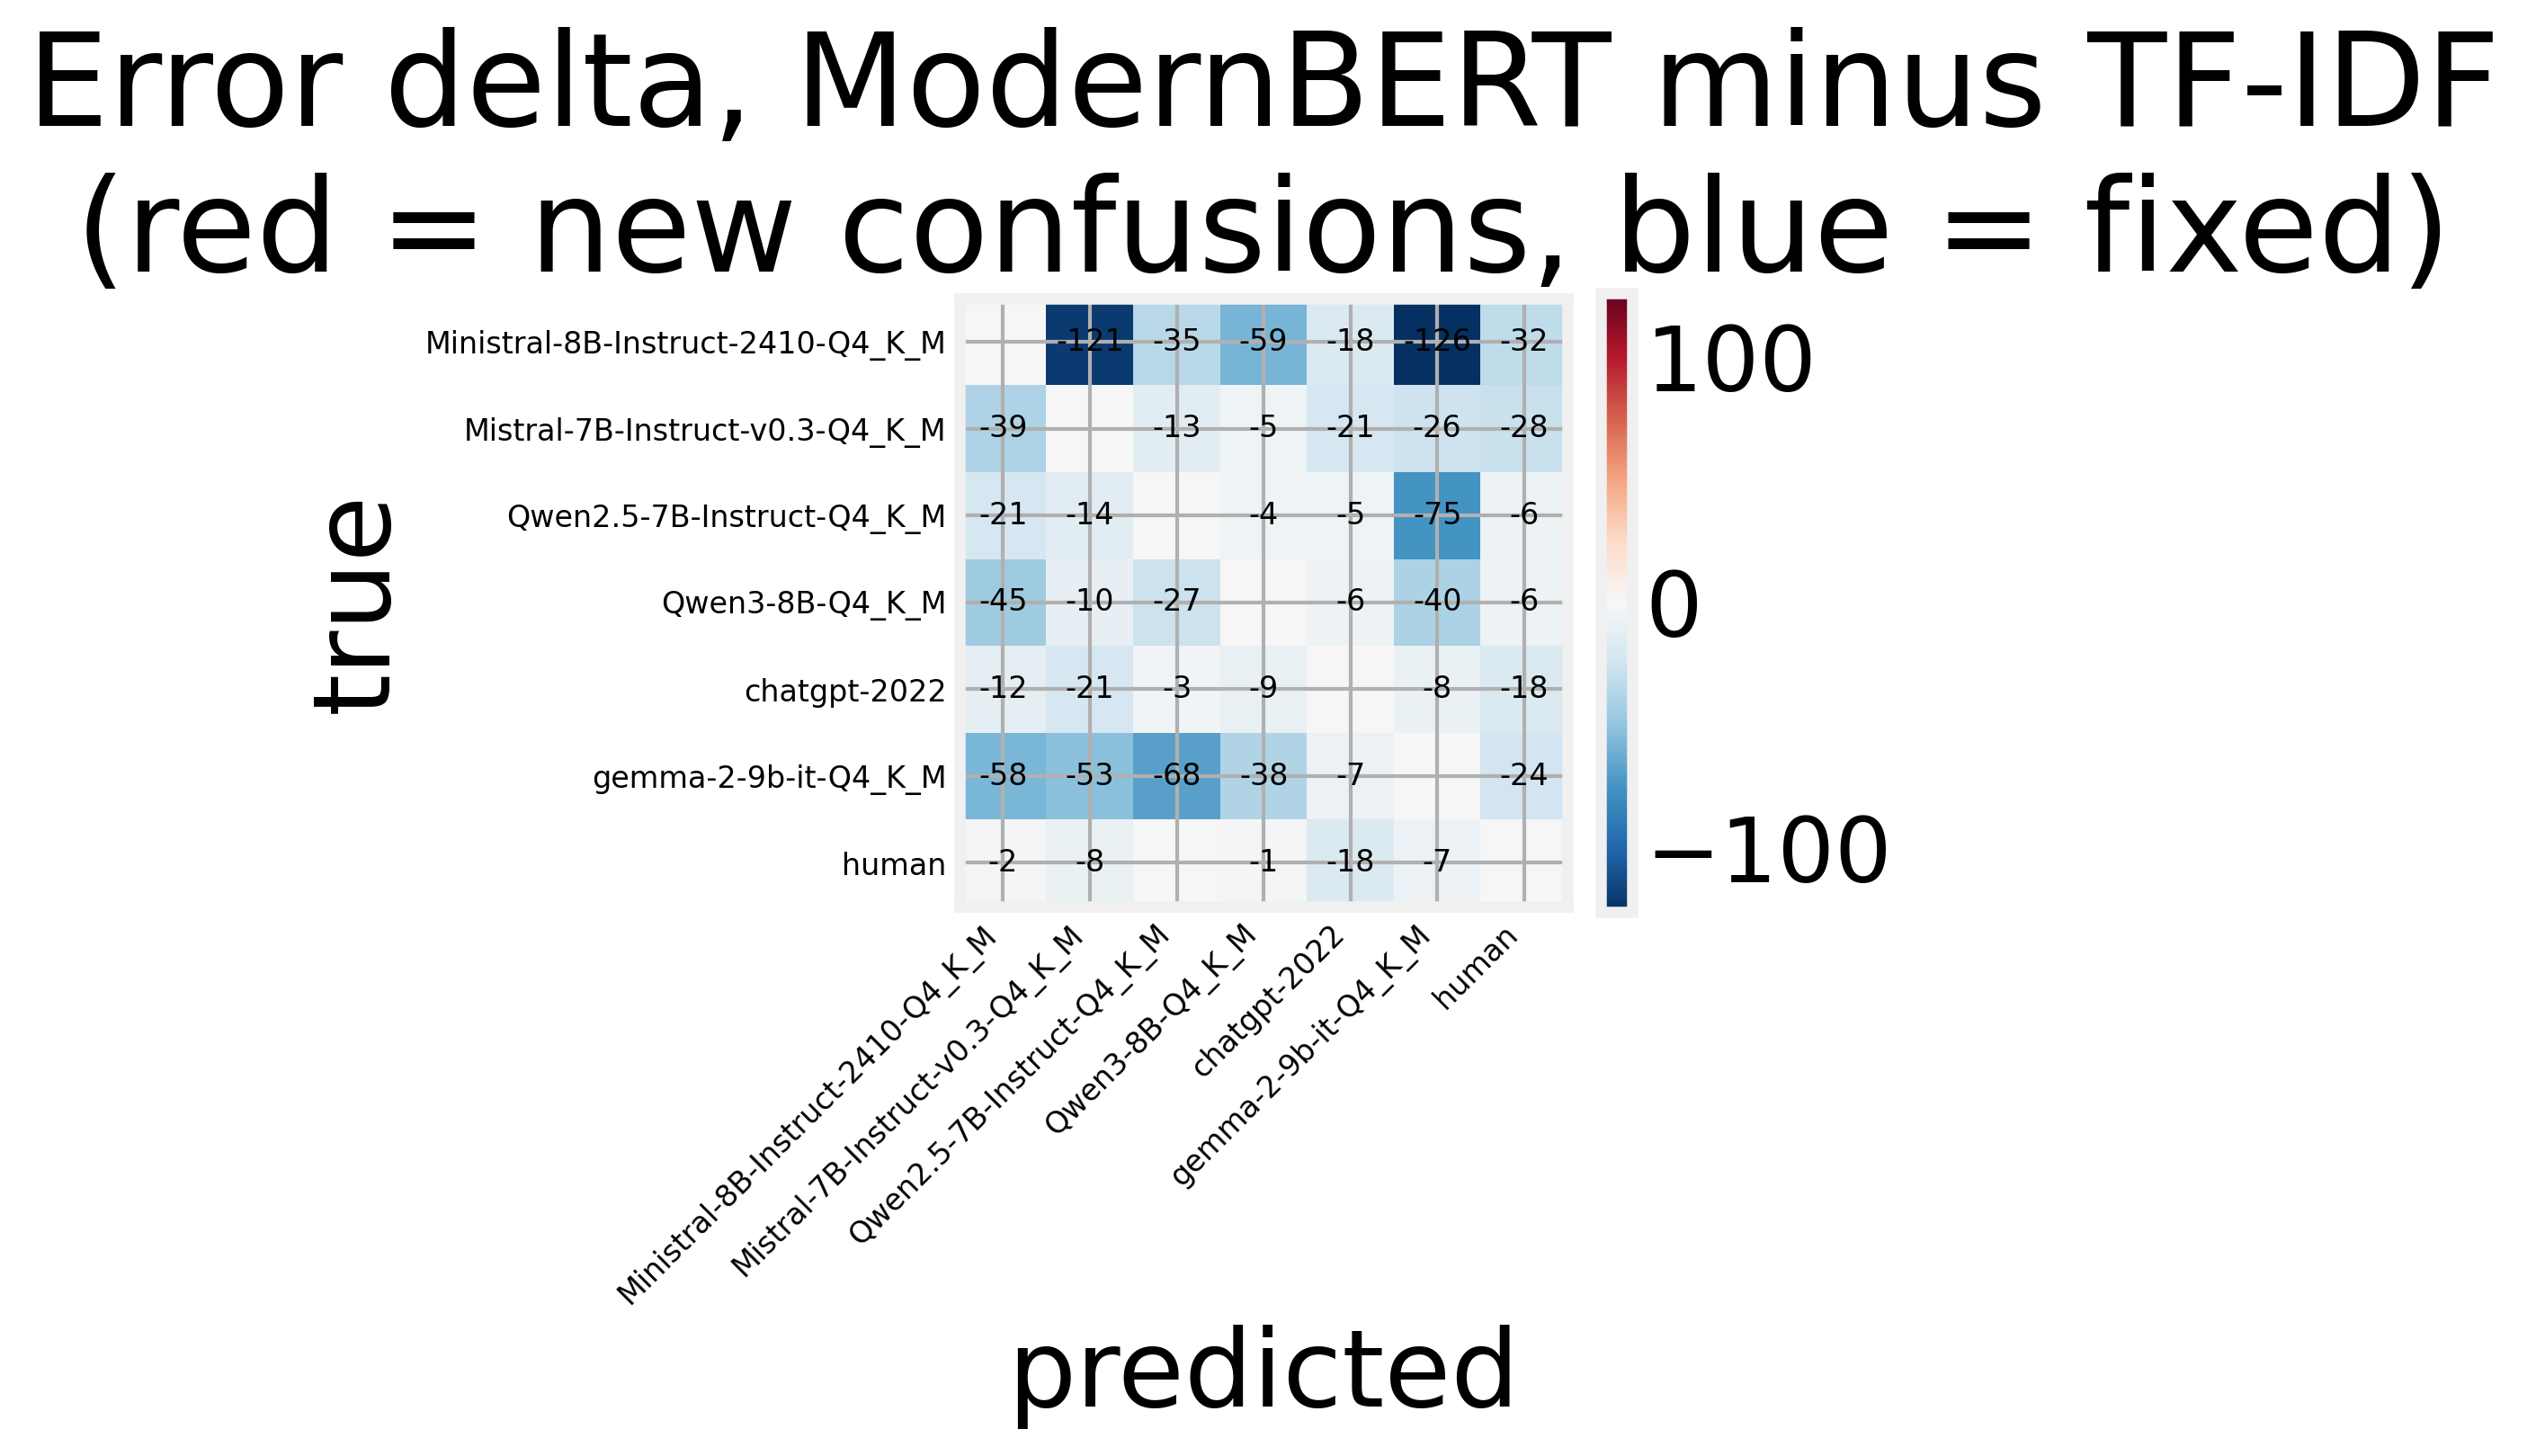

net correct per class, ModernBERT minus TF-IDF:
  Ministral-8B-Instruct-2410-Q4_K_M    +391
  gemma-2-9b-it-Q4_K_M                 +248
  Qwen3-8B-Q4_K_M                      +134
  Mistral-7B-Instruct-v0.3-Q4_K_M      +132
  Qwen2.5-7B-Instruct-Q4_K_M           +125
  chatgpt-2022                         +71
  human                                +36


In [27]:
# Why a delta matrix, diagonal zeroed: it isolates the confusions themselves — red cells
# are errors ModernBERT introduced, blue cells are errors it fixed. Diagonal gains print below.
if TRAIN_BASELINE:
    labels_sorted = sorted(comp.label.unique())
    cm_base = confusion_matrix(comp.label, comp.base_pred, labels=labels_sorted)
    cm_trf = confusion_matrix(comp.label, comp.trf_pred, labels=labels_sorted)
    delta = (cm_trf - cm_base).astype(float)
    diag_gain = np.diag(cm_trf) - np.diag(cm_base)
    np.fill_diagonal(delta, 0)

    lim = max(1, np.abs(delta).max())
    side = max(5, 1 + 0.8 * len(labels_sorted))
    fig, ax = plt.subplots(figsize=(side, side))
    im = ax.imshow(delta, cmap="RdBu_r", vmin=-lim, vmax=lim)
    ax.set_xticks(range(len(labels_sorted)))
    ax.set_yticks(range(len(labels_sorted)))
    ax.set_xticklabels(labels_sorted, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(labels_sorted, fontsize=8)
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.set_title("Error delta, ModernBERT minus TF-IDF\n(red = new confusions, blue = fixed)")
    for i in range(delta.shape[0]):
        for j in range(delta.shape[1]):
            if delta[i, j] != 0:
                ax.text(j, i, f"{delta[i, j]:+.0f}", ha="center", va="center", fontsize=8)
    fig.colorbar(im, fraction=0.046)
    plt.tight_layout()
    plt.show()

    print("net correct per class, ModernBERT minus TF-IDF:")
    for lab, g in sorted(zip(labels_sorted, diag_gain), key=lambda x: -x[1]):
        print(f"  {lab:36s} {g:+d}")

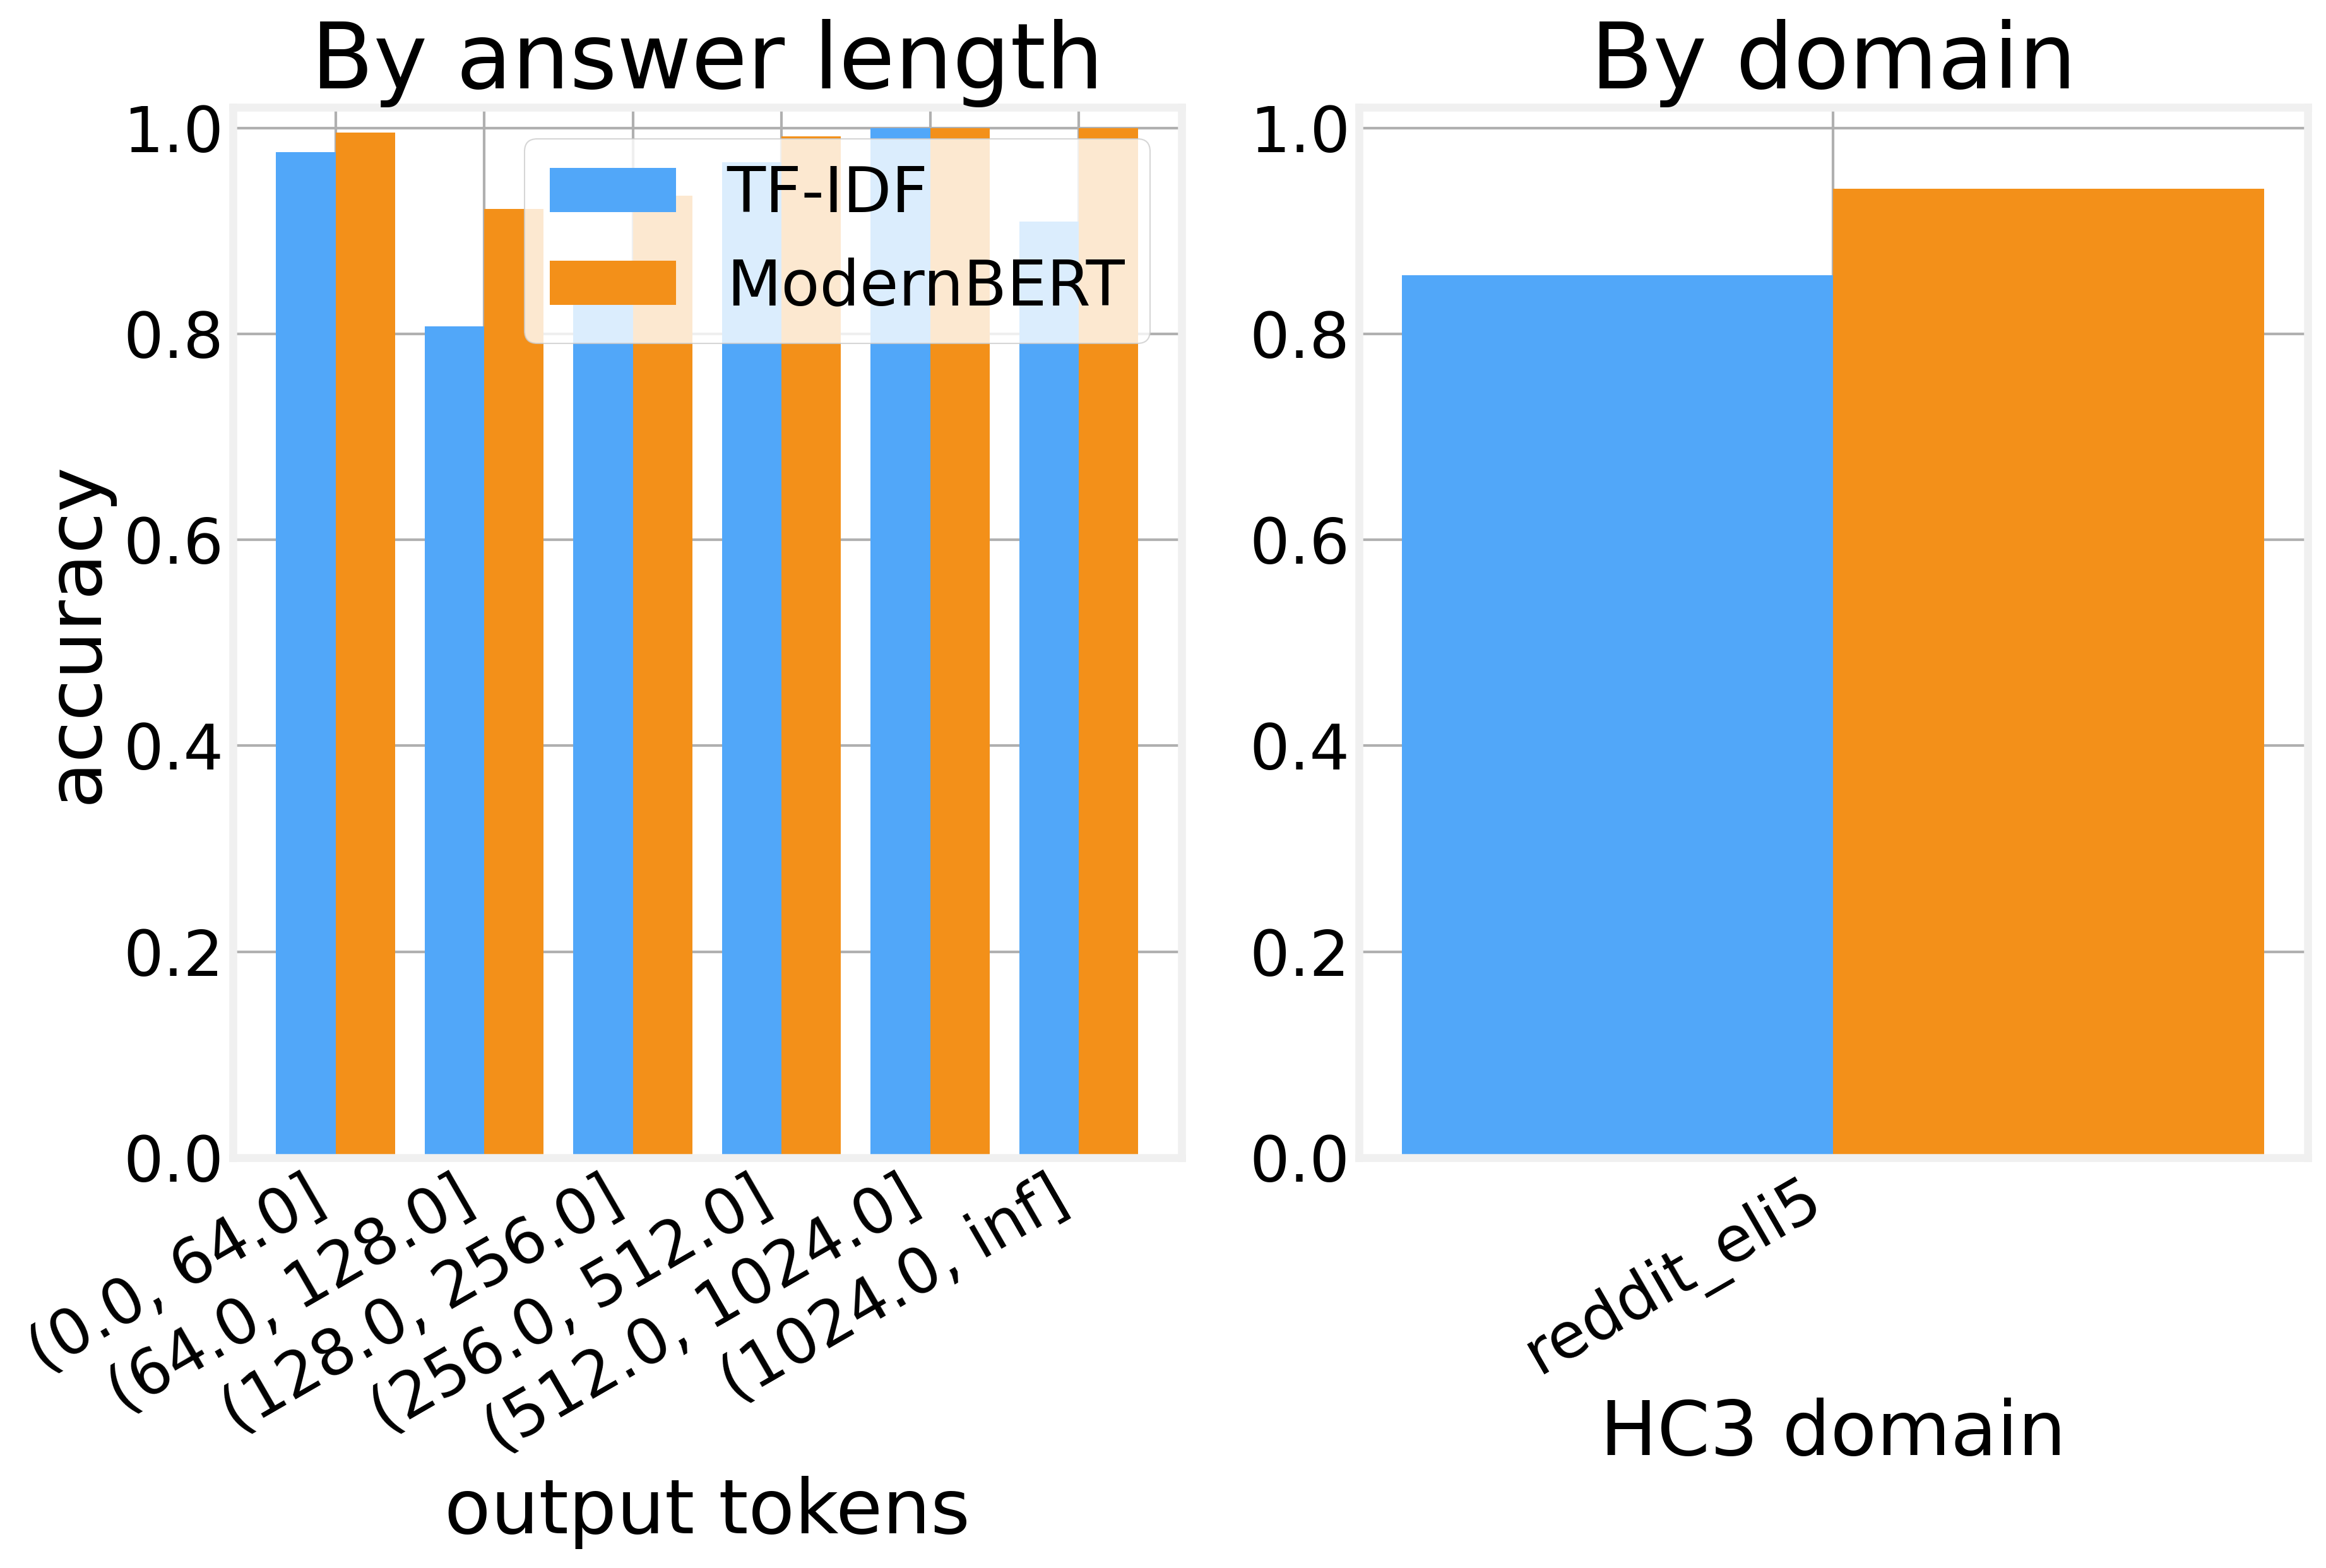

In [28]:
# Why these two slices again: the length panel now doubles as a truncation probe —
# ModernBERT reads only the first MAX_LEN tokens, the baseline reads everything.
if TRAIN_BASELINE:
    bins = pd.cut(comp.out_tokens, [0, 64, 128, 256, 512, 1024, np.inf])
    by_len2 = comp.groupby(bins, observed=True)[["base_correct", "trf_correct"]].mean()
    by_dom2 = comp.groupby("domain")[["base_correct", "trf_correct"]].mean() \
                  .sort_values("trf_correct")

    fig, axes = plt.subplots(1, 2)
    for ax, tbl, xlab in [(axes[0], by_len2, "output tokens"),
                          (axes[1], by_dom2, "HC3 domain")]:
        x = np.arange(len(tbl))
        ax.bar(x - 0.2, tbl.base_correct, width=0.4, color=C_BASE, label="TF-IDF")
        ax.bar(x + 0.2, tbl.trf_correct, width=0.4, color=C_TRF, label="ModernBERT")
        ax.set_xticks(x)
        ax.set_xticklabels([str(i) for i in tbl.index], rotation=30, ha="right")
        ax.set_xlabel(xlab)
        ax.set_ylim(0, 1.02)
    axes[0].set_ylabel("accuracy")
    axes[0].set_title("By answer length")
    axes[1].set_title("By domain")
    axes[0].legend()
    plt.tight_layout()
    plt.show()

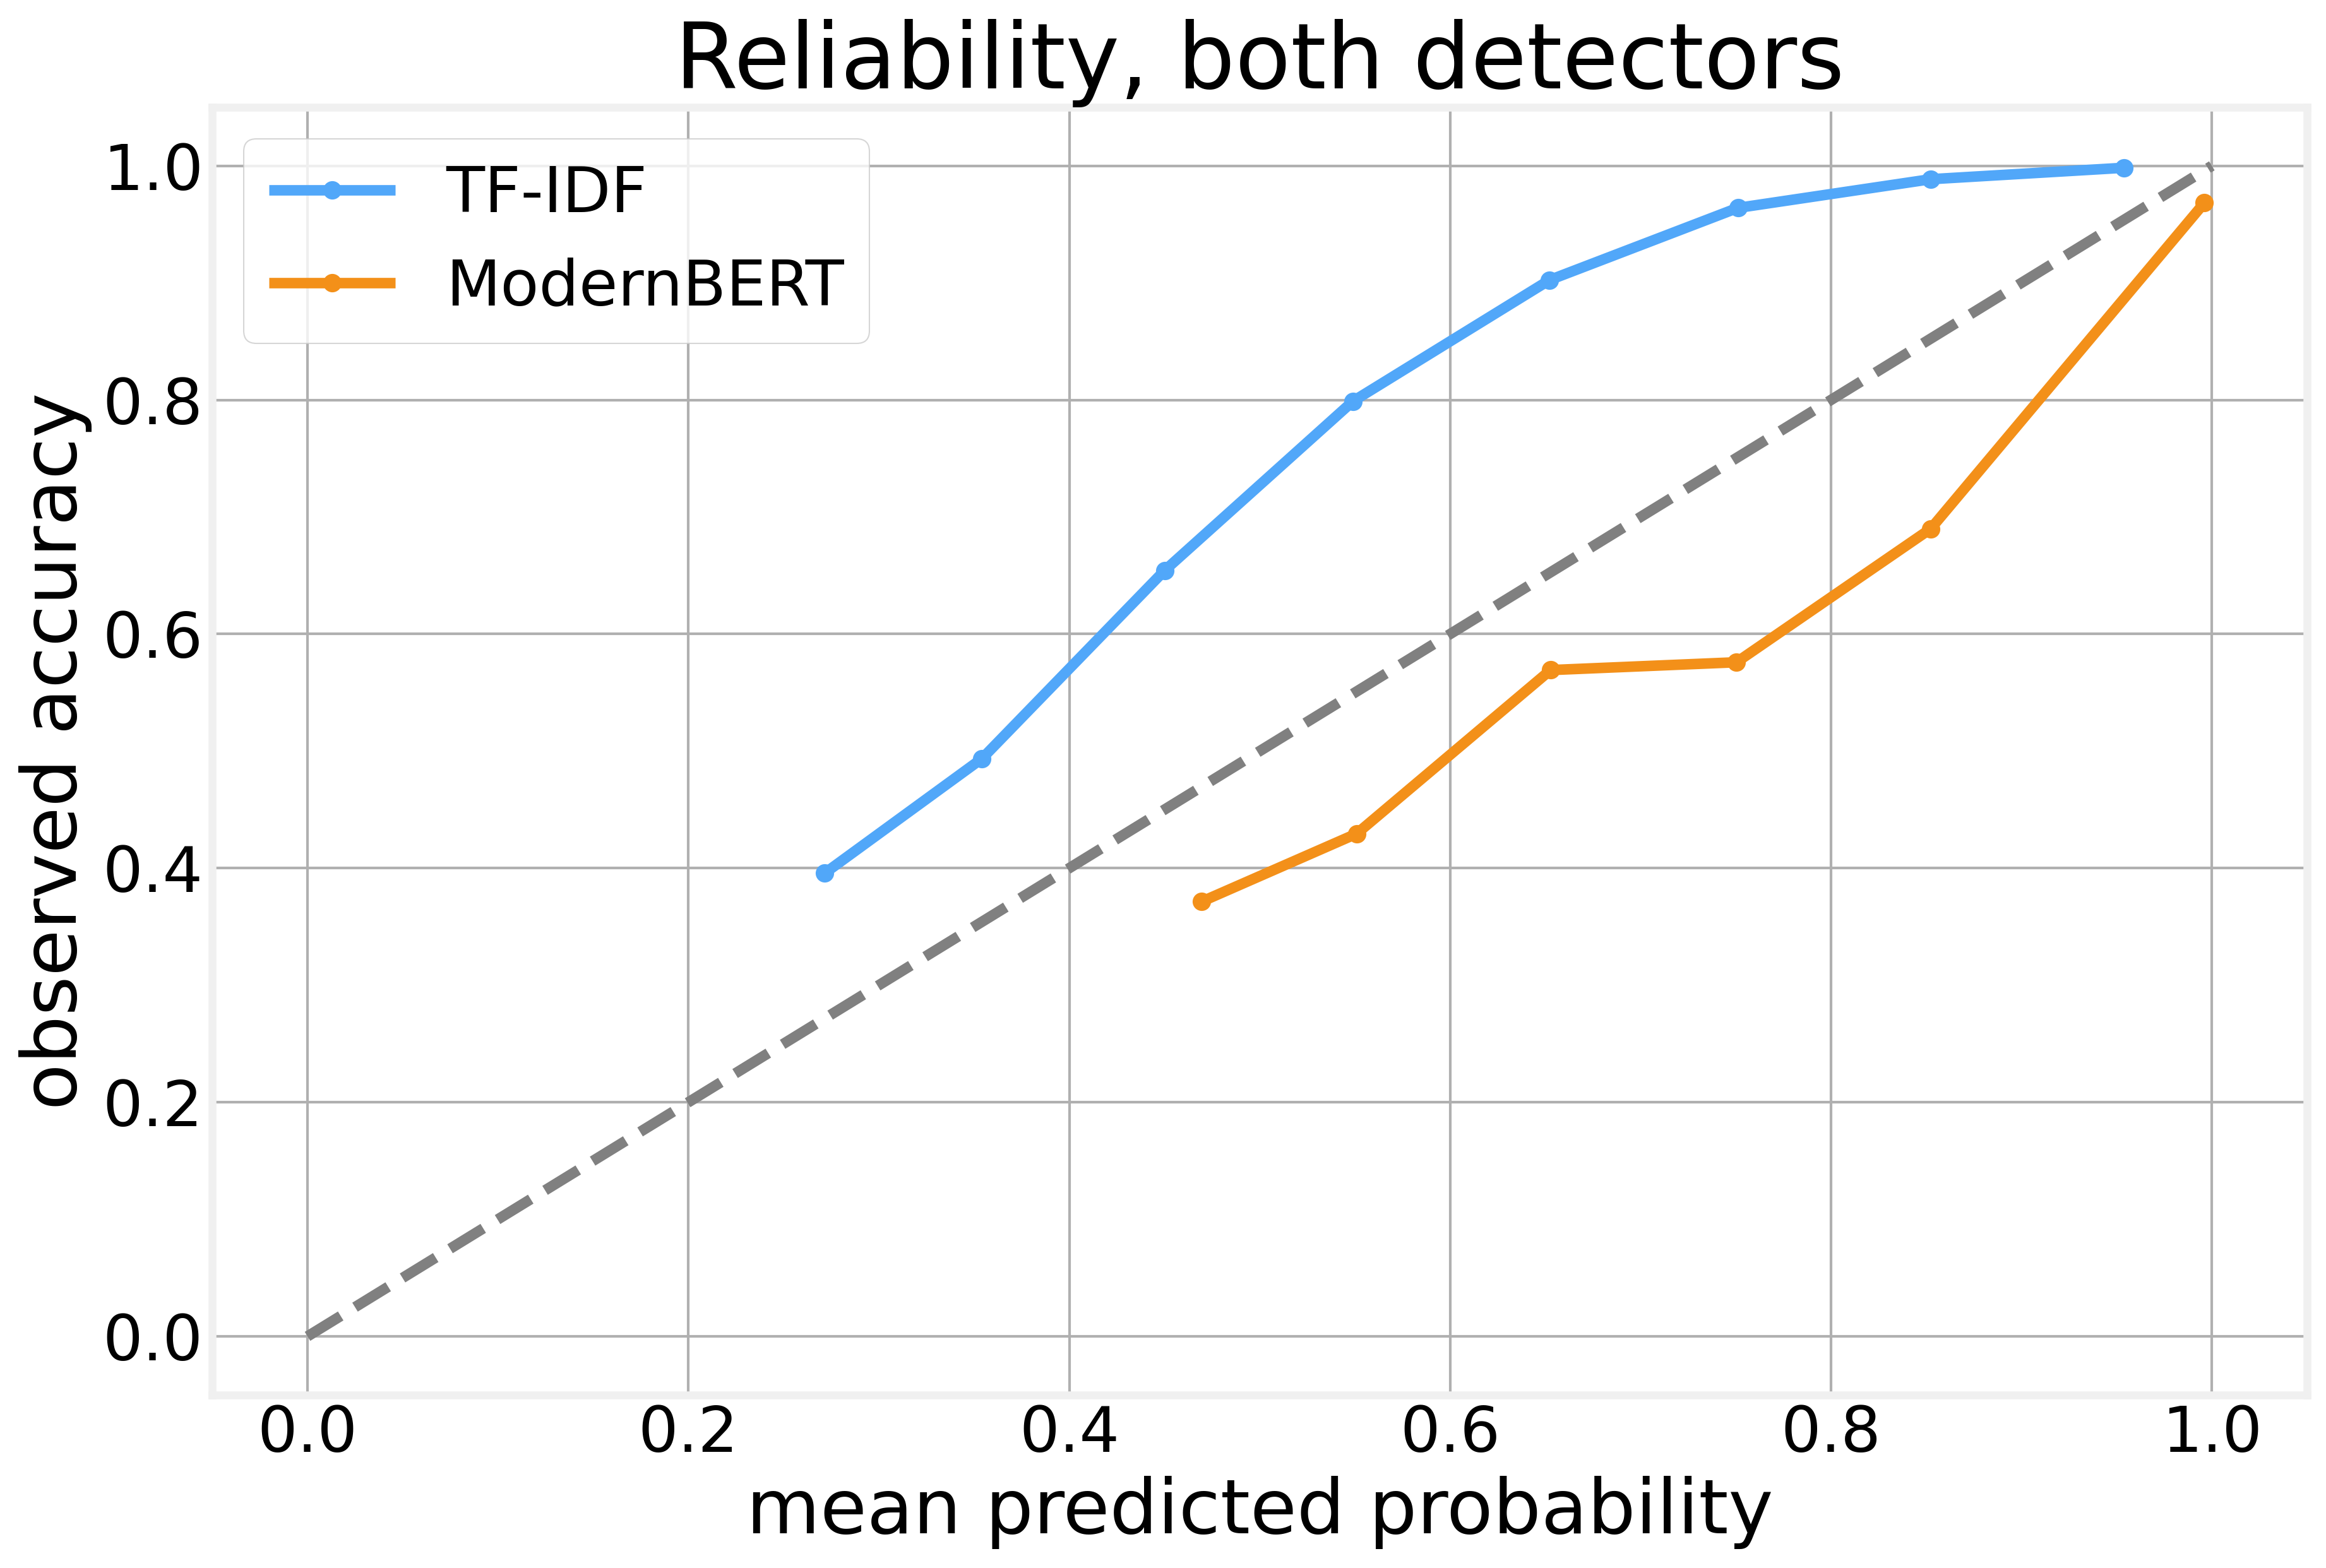

In [29]:
# Why one axes: the same bins, two curves — miscalibration is a distance, make it visible.
if TRAIN_BASELINE:
    fig, ax = plt.subplots()
    ax.plot([0, 1], [0, 1], "--", color="gray")
    for prefix, name, c in [("base", "TF-IDF", C_BASE), ("trf", "ModernBERT", C_TRF)]:
        maxp_c = comp[f"{prefix}_maxp"].values
        corr_c = comp[f"{prefix}_correct"].values
        bin_ids = np.clip(np.digitize(maxp_c, np.linspace(0, 1, 11)) - 1, 0, 9)
        mids = [maxp_c[bin_ids == b].mean() for b in range(10)
                if (bin_ids == b).sum() >= 20]
        obs = [corr_c[bin_ids == b].mean() for b in range(10)
               if (bin_ids == b).sum() >= 20]
        ax.plot(mids, obs, "o-", color=c, label=name)
    ax.set_xlabel("mean predicted probability")
    ax.set_ylabel("observed accuracy")
    ax.set_title("Reliability, both detectors")
    ax.legend()
    plt.tight_layout()
    plt.show()

In [30]:
# Why read the raw text: aggregate deltas say who wins, examples say what the winner saw.
if TRAIN_BASELINE:
    only_trf = comp[comp.trf_correct & ~comp.base_correct]
    only_base = comp[comp.base_correct & ~comp.trf_correct]

    def show(rows, title, n=3):
        print(f"{title} ({len(rows):,} rows)")
        for _, r in rows.sample(min(n, len(rows)), random_state=SEED).iterrows():
            print(f"  true {r.label} | tfidf {r.base_pred} ({r.base_maxp:.2f}) "
                  f"| modernbert {r.trf_pred} ({r.trf_maxp:.2f})")
            print(f"    {r.text[:180]!r}")
        print()

    show(only_trf, "ModernBERT right, TF-IDF wrong")
    show(only_base, "TF-IDF right, ModernBERT wrong")

ModernBERT right, TF-IDF wrong (1,437 rows)
  true Ministral-8B-Instruct-2410-Q4_K_M | tfidf Mistral-7B-Instruct-v0.3-Q4_K_M (0.42) | modernbert Ministral-8B-Instruct-2410-Q4_K_M (0.84)
    "Monarchies in Europe are like special clubs where a very old family heads the country. Just like a school's principal, they follow a set of rules that everyone agrees on. But unlik"
  true Ministral-8B-Instruct-2410-Q4_K_M | tfidf Mistral-7B-Instruct-v0.3-Q4_K_M (0.36) | modernbert Ministral-8B-Instruct-2410-Q4_K_M (1.00)
    'The United States decided to enter World War I because it was important for our country to help our friends and enemies avoid a total destruction. Initially, the U.S. tried to stay'
  true Qwen3-8B-Q4_K_M | tfidf Qwen2.5-7B-Instruct-Q4_K_M (0.52) | modernbert Qwen3-8B-Q4_K_M (0.95)
    'Imagine you have a really cool toy that everyone says is amazing. Even before you get to play with it, people start saying, "This toy is going to win the best toy award!" That’s ki'

TF-IDF ri

### Reading the comparison

The agreement bars frame everything: the two only-one-right bars are the whole argument, and McNemar's test says whether their imbalance is signal or noise. On the last full run the split was roughly four to one in ModernBERT's favor (1,349 rows only the transformer got right against 326 only the baseline got right, on pre-repair data), and the wins concentrated in the sibling confusions — the blue cells in the delta matrix — which is exactly the claim for context: the n-grams had exhausted the character-level signal on those pairs. If instead the per-class bars move together, the extra capacity bought nothing the characters didn't already carry.

The length panel carries a caveat: ModernBERT reads only the first `MAX_LEN` tokens, so the longest bins are the one place the baseline holds an information advantage. The reliability panel says whose probabilities to trust for triage — fine-tuned transformers tend to run overconfident, and a curve sagging below the diagonal at the right edge is the signature. The example rows close the loop: where the baseline loses on a Mistral-vs-Ministral answer it usually lost to a shared phrase both siblings love, and where ModernBERT loses it is usually a truncated long answer whose tell sat past token 256.

## Save the report

The ModernBERT checkpoint saved itself at training time and the baseline joblib saved in its own cell; what's left is the report JSON that stamps this detector with the data file, the class counts, the sampling defaults behind every class, and both detectors' scores — the provenance a future session needs to trust the checkpoint.

In [31]:
ts = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
out_dir = Path(RESULTS_DIR)

# The default sampling each model class generated with, straight off its rows.
sampling_by_label = {
    l: {k: float(v) for k, v in row.items()}
    for l, row in (data.dropna(subset=["temperature"])
                   .groupby("label")[["temperature", "top_p", "top_k"]]
                   .first().iterrows())}

report = {
    "run_id": ts,
    "host": platform.node(),
    "transformers": transformers.__version__,
    "torch": torch.__version__,
    "sklearn": sklearn.__version__,
    "dataset": {
        "file": GEN_FILE,
        "hc3_file": HC3_FILE,
        "human_class": ADD_HUMAN,
        "chatgpt_class": ADD_CHATGPT,
        "rows": len(data),
        "classes": {l: int(n) for l, n in data.groupby("label").size().items()},
        "sampling_by_label": sampling_by_label,
        "train_rows": len(train),
        "test_rows": len(test),
        "split": f"prompt_idx % {TEST_MOD} == 0 -> test",
        "balanced": BALANCE,
    },
    "detector": {
        "model": TRF_MODEL,
        "checkpoint": str(mb_dir),
        "max_len": MAX_LEN,
        "epochs": TRF_EPOCHS,
        "train_accuracy": round(float(acc_tr), 4),
        "test_accuracy": round(float(acc), 4),
        "train_macro_f1": round(float(macro_tr), 4),
        "test_macro_f1": round(float(macro), 4),
        "top_k_accuracy": {str(k): round(v, 4) for k, v in topk.items()},
        "per_class": classification_report(test.label, pred, output_dict=True),
        "accuracy_by_domain": {k: round(float(v), 4) for k, v in by_dom.items()},
    },
}
if TRAIN_BASELINE:
    report["baseline"] = {
        "model": "tfidf_char35_logreg",
        "fit_seconds": round(base_fit_s, 1),
        "test_accuracy": round(float(base_acc), 4),
        "test_macro_f1": round(float(base_macro), 4),
    }

with open(out_dir / f"detector_report__{ts}.json", "w") as f:
    json.dump(report, f, indent=2)
print("wrote", f"detector_report__{ts}.json")

wrote detector_report__20260820-221710.json


## Use it

In [32]:
# The deployed artifact is the checkpoint directory: tokenizer, weights, and the label
# map travel together, so this function is all a consumer needs.
def identify(text, k=3):
    enc_b = tok_mb([text], truncation=True, max_length=MAX_LEN,
                   return_tensors="pt").to(dev)
    with torch.no_grad():
        proba = torch.softmax(model_mb(**enc_b).logits.float(), dim=1)[0].cpu().numpy()
    order = np.argsort(proba)[::-1][:k]
    return [(str(classes_arr[i]), round(float(proba[i]), 3)) for i in order]

sample = test.sample(1, random_state=SEED).iloc[0]
print("text:", sample.text[:200])
print("true:", sample.label)
print("top guesses:", identify(sample.text))

text: Imagine your body needs to recharge like a battery after playing all day. Sleep is like plugging it in overnight to get all the energy back. When you don't get enough sleep, you're running on a low ba
true: gemma-2-9b-it-Q4_K_M
top guesses: [('gemma-2-9b-it-Q4_K_M', 0.867), ('Ministral-8B-Instruct-2410-Q4_K_M', 0.132), ('Qwen2.5-7B-Instruct-Q4_K_M', 0.001)]


Retrain by rerunning top to bottom after every new generation run. New models append to the combined JSONL and become new classes automatically — which also invalidates the cached ModernBERT checkpoint, since the training cell compares label sets before skipping. The one blind spot: a change that alters the text but not the classes (like the detokenization repair) slips past that check, so delete `RESULTS_DIR/detector_modernbert` by hand after any preprocessing change. The report JSON stamps each detector with the file, the class counts, and the sampling defaults behind it.

<center>
     <img src="data/D4Sci_logo_full.png" alt="Data For Science, Inc" align="center" border="0" width=300px>
</center>